<!-- <!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for Neural Network Models -->

<!-- ## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. | -->

<!-- ## **2. Import the necessary libraries** -->

In [1]:
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

np.random.seed(23)
torch.manual_seed(23)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(23)

<!-- ## **3. Loading the dataset** -->

In [2]:
# !curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
# !unzip -o data/clients.zip -d data
# !rm data/clients.zip

In [3]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<!-- ## **4. Create a PyTorch dataset**
Create a dataset class inherited from PyTorch Dataset to be input for model training. -->

In [4]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values


# Create a PyTorch Dataset
class CreditDataset(Dataset):
    """PyTorch Dataset for Credit data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # Reshape y to be column vector

    def __len__(self):
        """Return dataset length."""
        return len(self.X)

    def __getitem__(self, idx):
        """Get item at index."""
        return self.X[idx], self.y[idx]


# Create DataLoaders for batching
batch_size = 64
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

<!-- ## **5. Train a 3-layer MLP using PyTorch**
Let's train a simple 3-layer MLP to predict credit card defaults. -->

Epoch [10/125], Loss: 0.4300
Epoch [20/125], Loss: 0.4235
Epoch [30/125], Loss: 0.4203
Epoch [40/125], Loss: 0.4152
Epoch [50/125], Loss: 0.4112
Epoch [60/125], Loss: 0.4078
Epoch [70/125], Loss: 0.4068
Epoch [80/125], Loss: 0.4043
Epoch [90/125], Loss: 0.4011
Epoch [100/125], Loss: 0.3986
Epoch [110/125], Loss: 0.3970
Epoch [120/125], Loss: 0.3939
Accuracy: 0.8132
ROC AUC Score: 0.7593


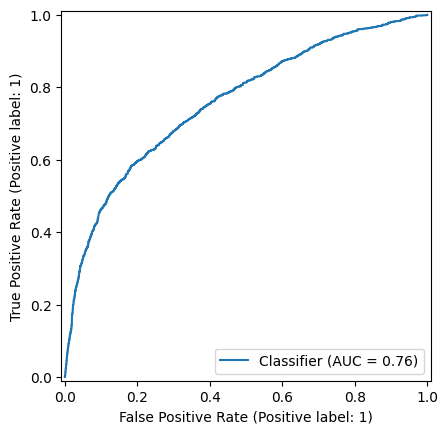

In [5]:
# Define the model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model in batches
num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
y_pred_probs = []
y_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        y_pred_probs.extend(outputs.numpy())  # Store predictions
        y_true.extend(batch_y.numpy())  # Store true labels

# Convert predictions to NumPy array
y_pred_probs = np.array(y_pred_probs).flatten()
y_true = np.array(y_true).flatten()

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

<!-- ## **6. Use SHAP to explain Neural network predictions** -->

In [6]:
# Use existing NumPy arrays
X_train_np = X_train
X_test_np = X_test

# Reduce background dataset for SHAP (using 200 samples instead of full training set)
background = shap.kmeans(X_train_np, 200)


# Wrapper function for PyTorch model inference
def model_wrapper(data):
    """Model wrapper for SHAP."""
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model(data_tensor).detach().numpy()
        # Should be (n_samples, n_classes)

# Use KernelExplainer with reduced background
explainer = shap.KernelExplainer(model_wrapper, background)


# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test_np[:50]


# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)  # Should be (n_samples, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should match (n_samples, n_features)

# Remove extra dimension if shap_values is (50, 23, 1)
shap_values = np.array(shap_values)  # Convert to NumPy array
if shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # Remove last dimension

# Ensure correct shape
print("Updated SHAP values shape:", shap_values.shape)  # Should be (50, 23)


# Generate SHAP summary plot
# shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

X_test_sample shape: (50, 23)
SHAP values shape: (50, 23, 1)
Updated SHAP values shape: (50, 23)


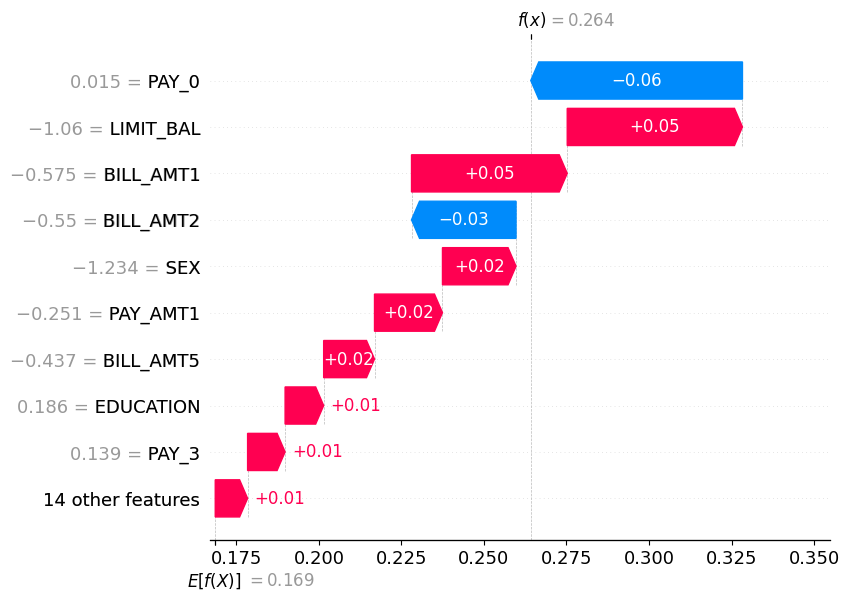

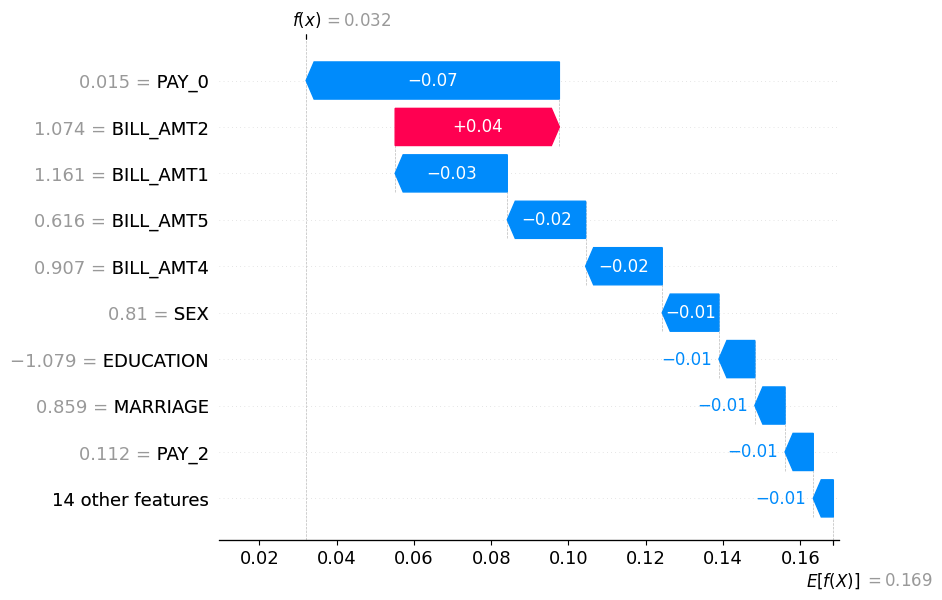

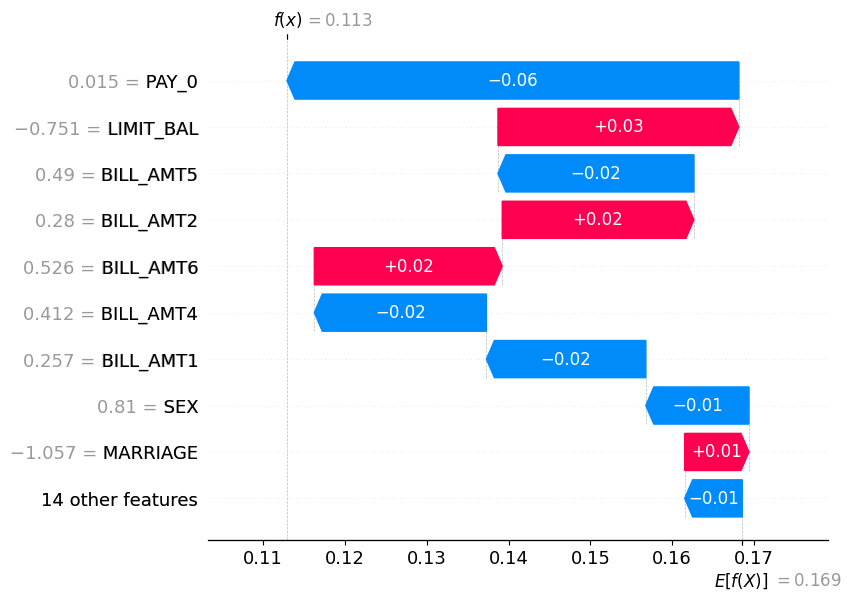

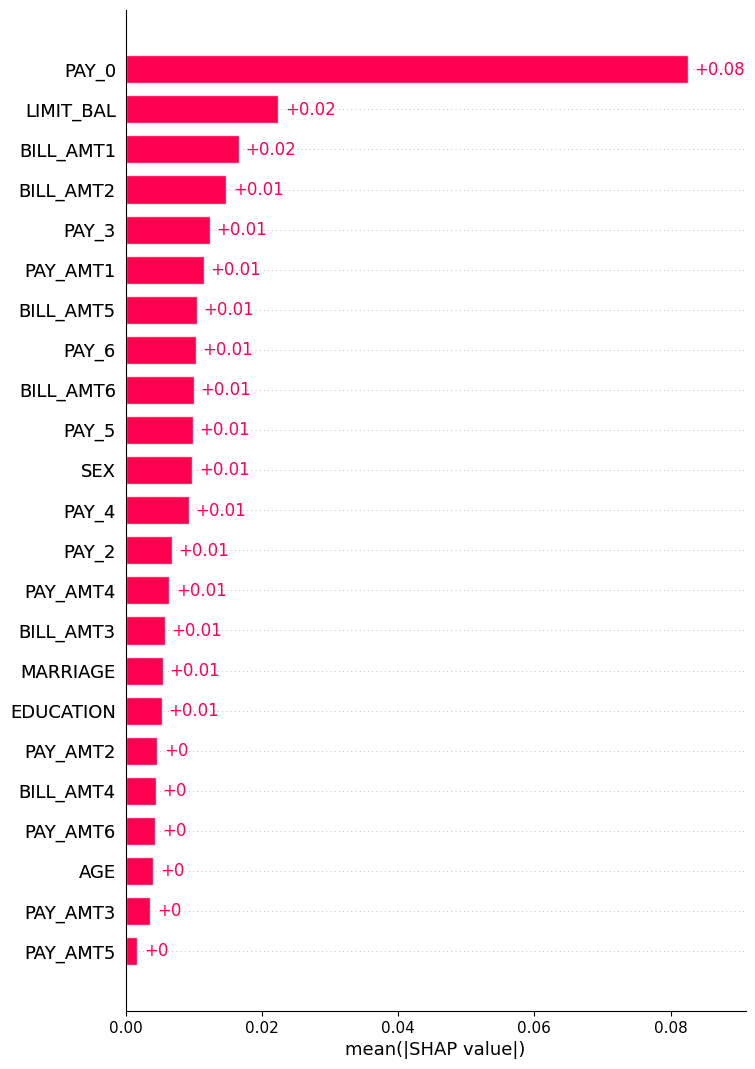

In [7]:
# Initialize SHAP JavaScript
shap.initjs()

# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

# Waterfall plots for first 3 samples
for i in range(3):
    shap.plots.waterfall(explanation[i])

# Global feature importance plot
shap.plots.bar(explanation, max_display=30)

<!-- # Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect. -->

In [8]:
# Compute correlation matrix
X_train_df = pd.DataFrame(X_train, columns=data.columns[1:-1])
correlation_matrix = X_train_df.corr()
# print(correlation_matrix)

In [9]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Create correlation heatmap with feature names
# plt.figure(figsize=(14, 12))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
#             xticklabels=True, yticklabels=True)
# plt.title('Feature Correlation Matrix')
# plt.tight_layout()
# plt.show()

In [10]:
# Find pairs with correlation > 0.7
def find_high_correlations(corr_matrix, threshold=0.7):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

high_corr = find_high_correlations(correlation_matrix, threshold=0.7)
print(high_corr.sort_values('Correlation', ascending=False, key=abs))

    Feature 1  Feature 2  Correlation
5   BILL_AMT1  BILL_AMT2     0.951598
19  BILL_AMT5  BILL_AMT6     0.946754
17  BILL_AMT4  BILL_AMT5     0.938511
10  BILL_AMT2  BILL_AMT3     0.925135
14  BILL_AMT3  BILL_AMT4     0.918356
18  BILL_AMT4  BILL_AMT6     0.900838
11  BILL_AMT2  BILL_AMT4     0.890216
6   BILL_AMT1  BILL_AMT3     0.888002
15  BILL_AMT3  BILL_AMT5     0.878807
12  BILL_AMT2  BILL_AMT5     0.859068
7   BILL_AMT1  BILL_AMT4     0.855804
16  BILL_AMT3  BILL_AMT6     0.850489
13  BILL_AMT2  BILL_AMT6     0.830404
8   BILL_AMT1  BILL_AMT5     0.827622
2       PAY_4      PAY_5     0.820118
4       PAY_5      PAY_6     0.814612
9   BILL_AMT1  BILL_AMT6     0.800231
1       PAY_3      PAY_4     0.777305
0       PAY_2      PAY_3     0.768607
3       PAY_4      PAY_6     0.715312


In [11]:
# Create a drop list based on high correlations
features_to_drop = []

# Find highly correlated pairs and keep only one from each pair
for _, row in high_corr.iterrows():
    # Drop the second feature from each pair to avoid duplicates
    if row['Feature 2'] not in features_to_drop:
        features_to_drop.append(row['Feature 2'])

print("Features to drop:", features_to_drop)

# Get feature names
feature_names = list(data.columns[1:-1])
print(f"Original features: {len(feature_names)}")
print(f"Dropping {len(features_to_drop)} features")

# Get indices of features to drop
drop_indices = [i for i, col in enumerate(feature_names) if col in features_to_drop]

# Remove correlated features from training and test data
X_train_reduced = np.delete(X_train, drop_indices, axis=1)
X_test_reduced = np.delete(X_test, drop_indices, axis=1)
X_test_sample_reduced = np.delete(X_test_sample, drop_indices, axis=1)

# Get remaining feature names
remaining_features = [col for col in feature_names if col not in features_to_drop]

print(f"Reduced features: {len(remaining_features)}")
print("Remaining features:", remaining_features)

Features to drop: ['PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Original features: 23
Dropping 9 features
Reduced features: 14
Remaining features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [12]:
# Retrain model with reduced features
model_reduced = nn.Sequential(
    nn.Linear(X_train_reduced.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model_reduced.parameters(), lr=0.001)

# Create datasets with reduced features
train_dataset_reduced = CreditDataset(X_train_reduced, y_train)
test_dataset_reduced = CreditDataset(X_test_reduced, y_test)

train_loader_reduced = DataLoader(train_dataset_reduced, batch_size=64, shuffle=True)
test_loader_reduced = DataLoader(test_dataset_reduced, batch_size=64, shuffle=False)

# Train the reduced model
num_epochs = 125
for epoch in range(num_epochs):
    model_reduced.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader_reduced:
        optimizer.zero_grad()
        outputs = model_reduced(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader_reduced)
        # print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate reduced model
model_reduced.eval()
y_pred_probs_reduced = []
with torch.no_grad():
    for batch_x, _ in test_loader_reduced:
        outputs = model_reduced(batch_x)
        y_pred_probs_reduced.extend(outputs.numpy())

y_pred_probs_reduced = np.array(y_pred_probs_reduced).flatten()
accuracy_reduced = ((y_pred_probs_reduced > 0.5) == y_test).mean()
roc_auc_reduced = roc_auc_score(y_test, y_pred_probs_reduced)
print(f"Reduced Model Accuracy: {accuracy_reduced:.4f}")
print(f"Reduced Model ROC AUC Score: {roc_auc_reduced:.4f}")

Reduced Model Accuracy: 0.8087
Reduced Model ROC AUC Score: 0.7581


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_17620/1182074343.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)


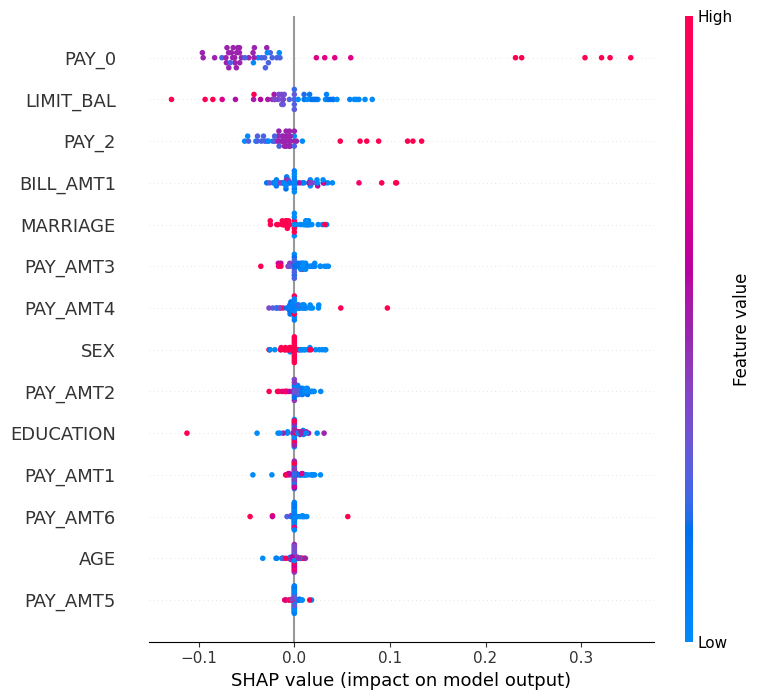

In [13]:
# Wrapper for reduced model
def model_wrapper_reduced(data):
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()

# Create SHAP explainer with reduced model
explainer_reduced = shap.KernelExplainer(model_wrapper_reduced, shap.kmeans(X_train_reduced, 200))

# Compute SHAP values
shap_values_reduced = explainer_reduced.shap_values(X_test_sample_reduced)
shap_values_reduced = np.array(shap_values_reduced).squeeze(-1) if np.array(shap_values_reduced).shape[-1] == 1 else shap_values_reduced

# Summary plot
shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)

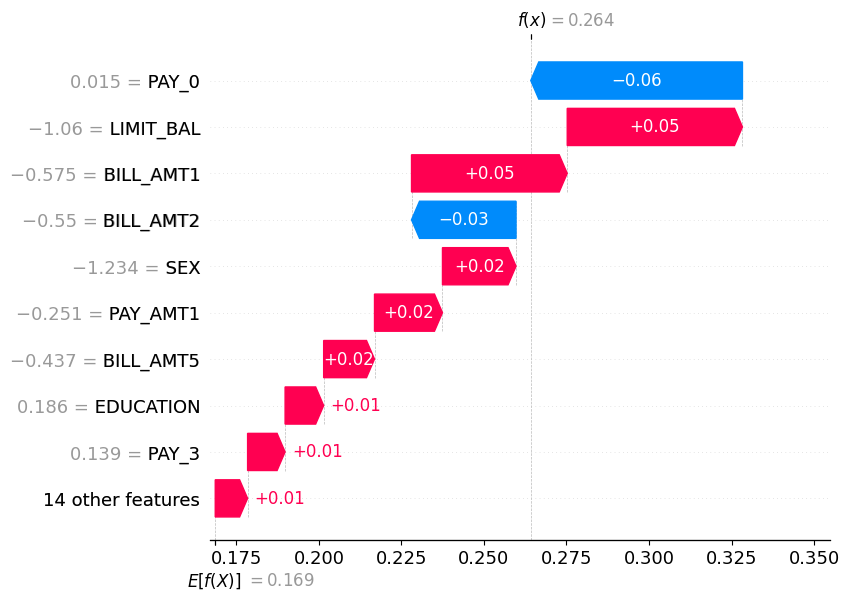

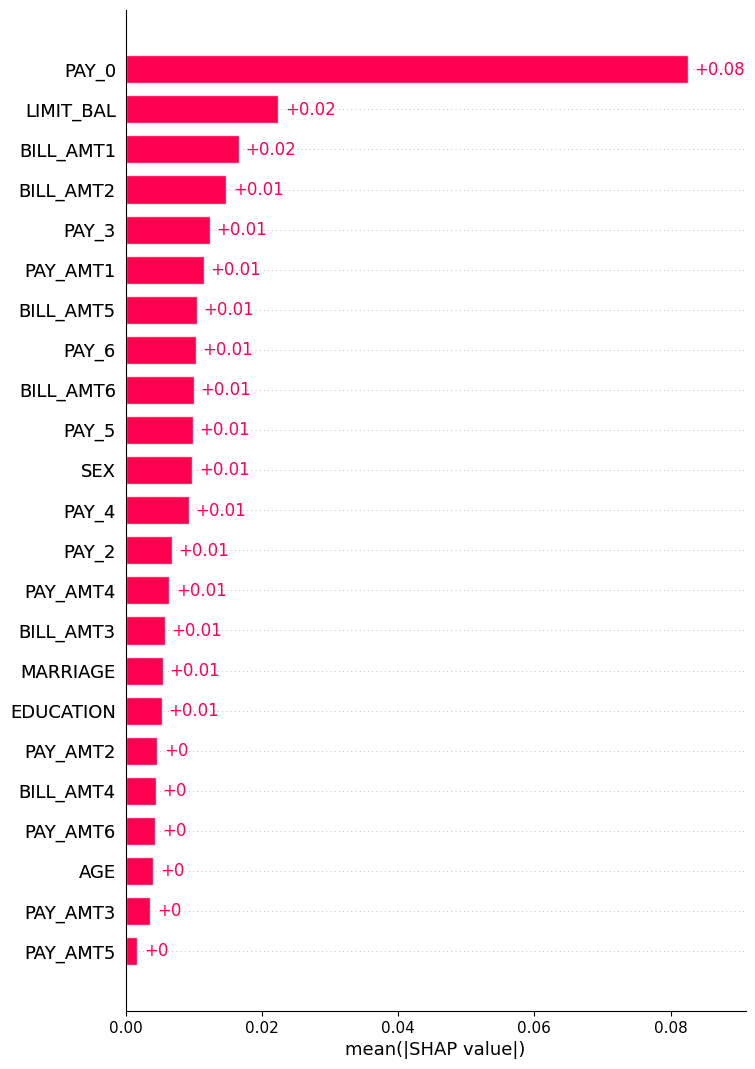

In [14]:
# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

shap.plots.waterfall(explanation[0])

shap.plots.bar(explanation, max_display=30)

<!-- # Final Model - Remove the sigmoid layer, SHAP on logits -->

THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)

1. Creating SHAP explainers...
   ✓ Explainers created

2. Computing SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

   ✓ SHAP values computed

3. Output Comparison (First 5 Samples):
Sample   Logits          Probability     SHAP Sum (Logits)    SHAP Sum (Probs)    
   --------------------------------------------------------------------------------
   0               -1.2884         0.2161              0.7237              0.0442
   1               -2.1166         0.1075             -0.1045             -0.0644
   2               -1.6865         0.1562              0.3256             -0.0157
   3               -2.2771         0.0930             -0.2650             -0.0789
   4               -1.4602         0.1884              0.5520              0.0165

4. Key Differences Between Logits and Probabilities:

   A. RANGE OF VALUES:
      Logits SHAP range:        [-1.1598, 1.8337]
      Probabilities SHAP range: [-0.1229, 0.3666]
      → Logit values are UNBOUNDED, probabilities are constrained [0,1]

   B. ADDITIVITY CHECK:
      Base value (logits):       -2.0121
      Base value (probabilities): 0.1719

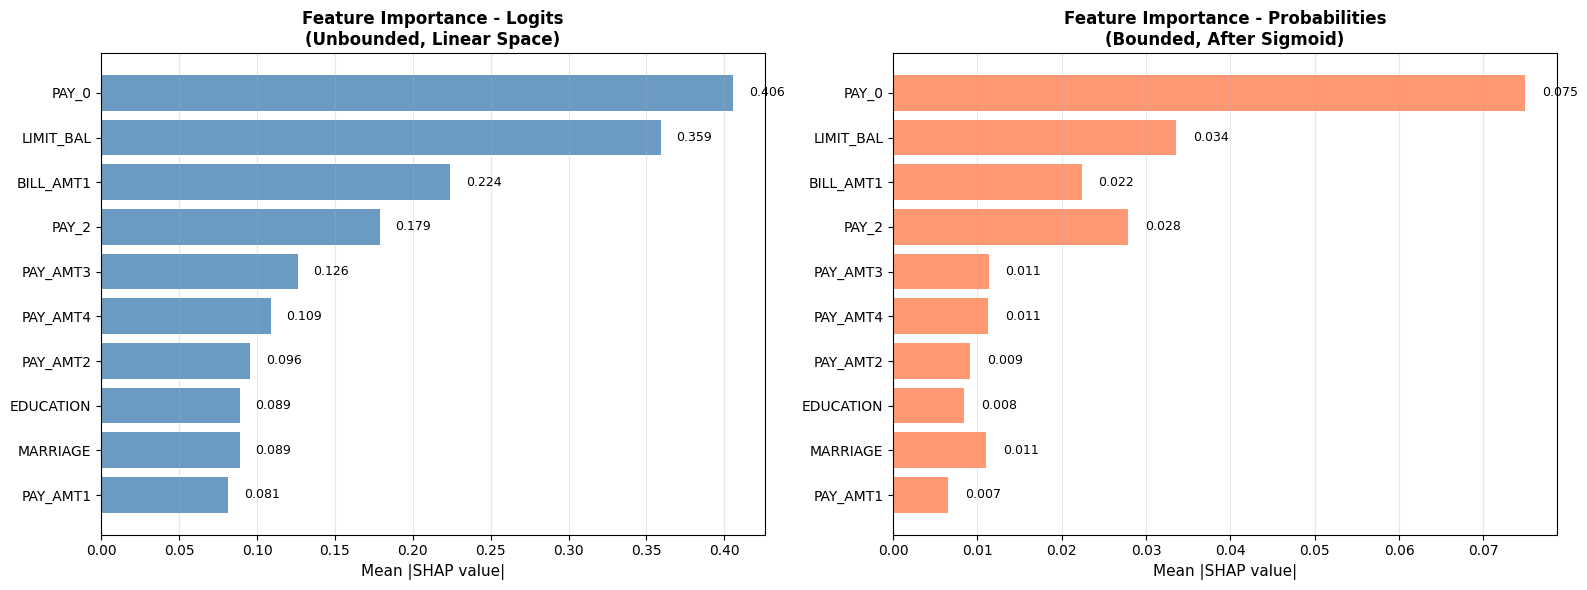

   ✓ Comparison plot saved


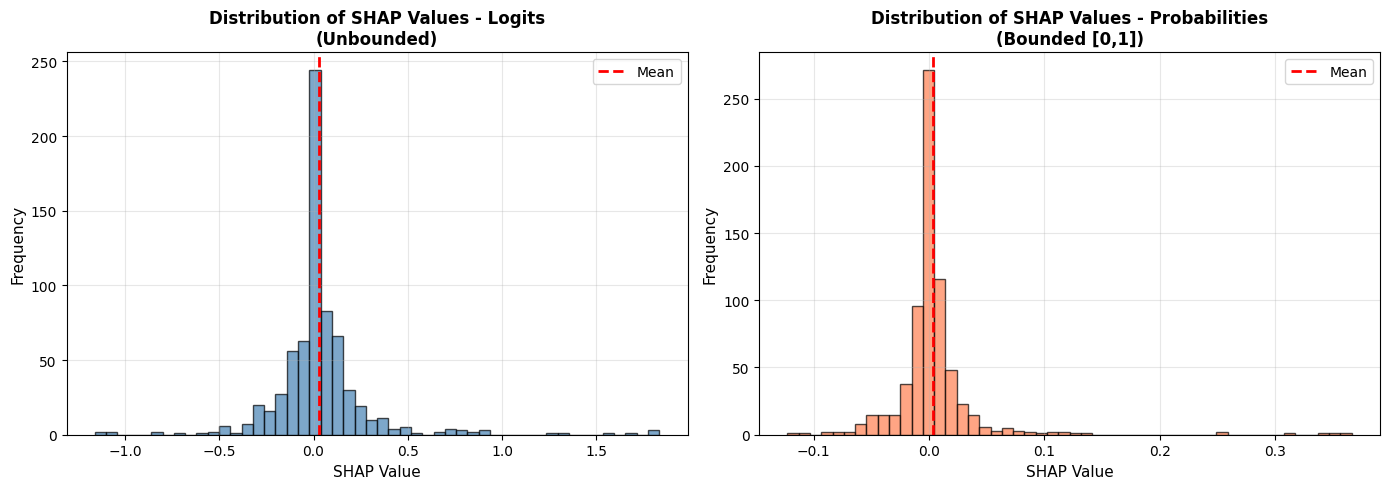

   ✓ Distribution plot saved

SUMMARY: Why SHAP on Logits is Mathematically Superior

MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE W

In [15]:
# ============================================================================
# SHAP on Logits (without sigmoid layer)
# Using model_reduced structure as template
# ============================================================================

import torch
import numpy as np
import shap
import matplotlib.pyplot as plt

print("=" * 80)
print("THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)")
print("=" * 80)

# ============================================================================
# Step 1: Model structure reference
# ============================================================================

# print("\nmodel_reduced structure:")
# print(model_reduced)

# print("\nModel layers breakdown:")
# for i, layer in enumerate(model_reduced):
#     print(f"  [{i}] {layer}")

# ============================================================================
# Step 2: Create model wrapper that outputs logits
# ============================================================================

def model_wrapper_logits(data):
    """
    Outputs logits by stopping before sigmoid (layer 6).
    Structure: [0-5] layers (exclude Sigmoid at [6])
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        
        # Forward through layers 0-5 (all except Sigmoid)
        x = data_tensor
        for i in range(6):  # 0 to 5 (excludes Sigmoid at index 6)
            x = model_reduced[i](x)
        
        return x.detach().numpy()


def model_wrapper_probabilities(data):
    """
    Outputs probabilities using full model with sigmoid.
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()


# ============================================================================
# Step 3: Create SHAP explainers
# ============================================================================

print("\n1. Creating SHAP explainers...")

background_data = shap.kmeans(X_train_reduced, 100)

explainer_logits = shap.KernelExplainer(model_wrapper_logits, background_data)
explainer_probs = shap.KernelExplainer(model_wrapper_probabilities, background_data)

print("   ✓ Explainers created")

# ============================================================================
# Step 4: Compute SHAP values
# ============================================================================

print("\n2. Computing SHAP values...")

shap_values_logits = explainer_logits.shap_values(X_test_sample_reduced)
shap_values_logits = np.array(shap_values_logits).squeeze()

shap_values_probs = explainer_probs.shap_values(X_test_sample_reduced)
shap_values_probs = np.array(shap_values_probs).squeeze()

print("   ✓ SHAP values computed")

# ============================================================================
# Step 5: Output comparison
# ============================================================================

print("\n3. Output Comparison (First 5 Samples):")
print("   " + "=" * 80)

logits_output = model_wrapper_logits(X_test_sample_reduced[:5])
probs_output = model_wrapper_probabilities(X_test_sample_reduced[:5])

print(f"{'Sample':<8} {'Logits':<15} {'Probability':<15} {'SHAP Sum (Logits)':<20} {'SHAP Sum (Probs)':<20}")
print("   " + "-" * 80)

for i in range(5):
    logit_val = logits_output[i, 0]
    prob_val = probs_output[i, 0]
    shap_sum_logits = np.sum(shap_values_logits[i])
    shap_sum_probs = np.sum(shap_values_probs[i])
    
    print(f"   {i:<8} {logit_val:>14.4f} {prob_val:>14.4f} {shap_sum_logits:>19.4f} {shap_sum_probs:>19.4f}")

print("   " + "=" * 80)

# ============================================================================
# Step 6: Key differences analysis
# ============================================================================

print("\n4. Key Differences Between Logits and Probabilities:")
print("   " + "=" * 80)

print("\n   A. RANGE OF VALUES:")
print(f"      Logits SHAP range:        [{np.min(shap_values_logits):.4f}, {np.max(shap_values_logits):.4f}]")
print(f"      Probabilities SHAP range: [{np.min(shap_values_probs):.4f}, {np.max(shap_values_probs):.4f}]")
print(f"      → Logit values are UNBOUNDED, probabilities are constrained [0,1]")

print("\n   B. ADDITIVITY CHECK:")
print(f"      Base value (logits):       {explainer_logits.expected_value[0]:.4f}")
print(f"      Base value (probabilities): {explainer_probs.expected_value[0]:.4f}")

# Verify additivity for sample 0
sample_idx = 0
logit_reconstruction = explainer_logits.expected_value[0] + np.sum(shap_values_logits[sample_idx])
actual_logit = logits_output[sample_idx, 0]

print(f"\n      Sample {sample_idx} (Logits - Perfect Linear Decomposition):")
print(f"        Base value + SHAP sum = {explainer_logits.expected_value[0]:.4f} + {np.sum(shap_values_logits[sample_idx]):.4f}")
print(f"                              = {logit_reconstruction:.4f}")
print(f"        Actual logit output   = {actual_logit:.4f}")
print(f"        Reconstruction error  = {abs(logit_reconstruction - actual_logit):.8f}")
print(f"      ✓ PERFECT additivity in log-odds space (linear before sigmoid)")

print("\n   C. FEATURE CONTRIBUTION BOUNDS:")
print(f"      Logits (max |SHAP|):       {np.max(np.abs(shap_values_logits)):.4f} (unbounded)")
print(f"      Probabilities (max |SHAP|): {np.max(np.abs(shap_values_probs)):.4f} (bounded by 0-1)")

print("   " + "=" * 80)

# ============================================================================
# Step 7: Visualization - Feature Importance Comparison
# ============================================================================

print("\n5. Generating comparison plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feature_importance_logits = np.abs(shap_values_logits).mean(axis=0)
feature_importance_probs = np.abs(shap_values_probs).mean(axis=0)

# Top 10 features by logits importance
sort_idx = np.argsort(feature_importance_logits)[::-1][:10]
feature_names_sorted = [remaining_features[i] for i in sort_idx]

# Plot 1: Logits
ax1 = axes[0]
x_pos = np.arange(len(sort_idx))
bars1 = ax1.barh(x_pos, feature_importance_logits[sort_idx], alpha=0.8, color='steelblue')
ax1.set_yticks(x_pos)
ax1.set_yticklabels(feature_names_sorted, fontsize=10)
ax1.set_xlabel('Mean |SHAP value|', fontsize=11)
ax1.set_title('Feature Importance - Logits\n(Unbounded, Linear Space)', 
              fontweight='bold', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_logits[sort_idx])):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: Probabilities
ax2 = axes[1]
bars2 = ax2.barh(x_pos, feature_importance_probs[sort_idx], alpha=0.8, color='coral')
ax2.set_yticks(x_pos)
ax2.set_yticklabels(feature_names_sorted, fontsize=10)
ax2.set_xlabel('Mean |SHAP value|', fontsize=11)
ax2.set_title('Feature Importance - Probabilities\n(Bounded, After Sigmoid)', 
              fontweight='bold', fontsize=12)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_probs[sort_idx])):
    ax2.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
# plt.savefig('shap_logits_vs_probs.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Comparison plot saved")

# ============================================================================
# Step 8: Distribution comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SHAP value distributions
ax1 = axes[0]
ax1.hist(shap_values_logits.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('SHAP Value', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of SHAP Values - Logits\n(Unbounded)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)
ax1.axvline(np.mean(shap_values_logits), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.legend()

ax2 = axes[1]
ax2.hist(shap_values_probs.flatten(), bins=50, alpha=0.7, color='coral', edgecolor='black')
ax2.set_xlabel('SHAP Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of SHAP Values - Probabilities\n(Bounded [0,1])', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)
ax2.axvline(np.mean(shap_values_probs), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.legend()

plt.tight_layout()
# plt.savefig('shap_distribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Distribution plot saved")

# ============================================================================
# Step 9: Summary & Interpretation
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY: Why SHAP on Logits is Mathematically Superior")
print("=" * 80)

summary = """
MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE WHICH:
   • Model interpretation:     Use LOGITS ✓
   • Report to stakeholders:   Convert logits → probs for communication
   • Feature importance:       Compute on logits, present on probs scale
   • Debugging model:          Always use logits first

RECOMMENDATION:
Always compute SHAP on logits for neural networks with sigmoid output layers.
Convert to probability scale only for final reporting/visualization.
"""

print(summary)
print("=" * 80)

# Store results
results_summary = {
    'explainer_logits': explainer_logits,
    'explainer_probs': explainer_probs,
    'shap_values_logits': shap_values_logits,
    'shap_values_probs': shap_values_probs,
    'base_value_logits': explainer_logits.expected_value[0],
    'base_value_probs': explainer_probs.expected_value[0],
}

print("\n✓ Results stored in 'results_summary' dictionary")

<!-- # Section 8: LLM Summary + Faithful Evaluation Pipeline

This section implements an end-to-end pipeline for:
1. Generating LLM-based global and local SHAP summaries
2. Evaluating faithfulness using automated scoring and LLM-as-judge
3. Testing consistency via perturbation analysis

**Requirements:**
- GEMINI API key set in environment variable `GEMINI_API_KEY`
- Dependencies: `google`, `numpy`, `json`

**Notes:**
- Uses GEMINI model for LLM explanations
- Requires variables from previous cells: `model_reduced`, `explainer_reduced`, `shap_values_reduced`, `X_test_sample_reduced`, `remaining_features` -->


In [16]:
pip install -U google-genai

Note: you may need to restart the kernel to use updated packages.


In [17]:
# ============================================================
# Step 1: Setup - Imports and Gemini Client and Langfuse
# ============================================================

import json
from google import genai
import numpy as np
import os
from dotenv import load_dotenv
from langfuse import Langfuse   
from langfuse import get_client

load_dotenv() 
langfuse = get_client()  # preferred client init

# Initialize Gemini client (reads GEMINI_API_KEY from environment)
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
MODEL = "gemini-2.5-flash-lite"
TOP_K = 5  # number of top SHAP features to consider

# Get base value from the explainer
base_value = float(explainer_probs.expected_value)
print(f"Base value (expected model output): {base_value:.4f}")

Base value (expected model output): 0.1719


/tmp/ipykernel_17620/2337768054.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_value = float(explainer_probs.expected_value)


<!-- ## 8.1 Global SHAP Summary (Zero-Shot Prompting) -->

In [35]:
def build_global_prompt(shap_values, feature_names, base_val, top_k=TOP_K):
    """Improved with explicit direction language"""
    
    mean_abs = np.abs(shap_values).mean(axis=0)
    mean_dir = shap_values.mean(axis=0)
    ranked = np.argsort(mean_abs)[::-1]
    
    # Generate explicit directions
    rows = []
    for rank, i in enumerate(ranked[:top_k], 1):
        direction = "INCREASES risk" if mean_dir[i] > 0 else "DECREASES risk"
        rows.append(
            f"  {rank}. {feature_names[i]}: "
            f"mean |SHAP| = {mean_abs[i]:.4f}, "
            f"direction = {direction} (SHAP {'+' if mean_dir[i] > 0 else ''}{mean_dir[i]:.4f})"
        )
    block = "\n".join(rows)
    
    feature_list = ", ".join([feature_names[i] for i in ranked[:top_k]])
    
    prompt = f"""You are an ML interpretability expert reviewing a credit card default prediction model.

Top {top_k} globally important features:
{block}

Base value (expected model output): {base_val:.4f}

**CRITICAL REQUIREMENTS:**
1. Explicitly state each feature using "INCREASES" or "DECREASES" language
2. Reference the actual SHAP values when discussing direction
3. Discuss business logic: WHY these features influence default risk
4. Identify RISK FACTORS (positive SHAP) vs PROTECTIVE FACTORS (negative SHAP)
5. Must mention all {top_k} features: {feature_list}

Write 12-18 sentences covering:
- Dominant risk factors (positive SHAP)
- Protective factors (negative SHAP)  
- Feature interactions or trade-offs
- Business implications
- Recommended actions

Use explicit language throughout. Avoid vague terms like "important" or "contributes."
"""
    return prompt, ranked[:top_k]


def get_global_summary(shap_values, feature_names, base_val):
    """
    Generate a global SHAP summary using Gemini.
    
    Returns:
        summary_text: The LLM-generated summary
        top_idx: Indices of top-K features
    """
    prompt, top_idx = build_global_prompt(shap_values, feature_names, base_val)
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    return resp.text, top_idx

print("✓ Global summary functions defined")

✓ Global summary functions defined


In [36]:
# # ============================================================
# # EXECUTE: Test Global Summary
# # ============================================================

# print("=" * 80)
# print("EXECUTING: Global SHAP Summary Generation")
# print("=" * 80)

# # Generate global summary using LLM
# global_summary, global_top_idx = get_global_summary(
#     shap_values_logits, remaining_features, base_value
# )

# print("\nGLOBAL SUMMARY OUTPUT:")
# print("-" * 80)
# print(global_summary)
# print("-" * 80)
# print(f"\nTop feature indices: {global_top_idx}")
# print(f"Top features: {[remaining_features[i] for i in global_top_idx]}")


<!-- ## 8.2 Local SHAP Summary (In-Context Learning) -->

In [37]:
# Curated few-shot reference examples for in-context learning
ICL_EXAMPLES = """
--- Reference Example 1: HIGH-RISK Profile ---
SHAP values: PAY_0(+0.18), LIMIT_BAL(-0.09), PAY_2(+0.07), AGE(-0.03)
Prediction: 0.72 (high risk)

**BAD** (vague):
"PAY_0 is important for this prediction. LIMIT_BAL helps somewhat."

**GOOD** (explicit directions):
"PAY_0 (+0.18) INCREASES default risk substantially—the September payment delay is the strongest 
risk factor here. In contrast, LIMIT_BAL (-0.09) DECREASES risk, providing some protection. 
PAY_2 (+0.07) also INCREASES risk as part of a consecutive delay pattern."

--- Reference Example 2: LOW-RISK Profile ---
SHAP values: PAY_0(-0.15), LIMIT_BAL(+0.11), PAY_2(-0.08), AGE(+0.04)
Prediction: 0.08 (low risk)

**GOOD (explicit directions)**:
"PAY_0 (-0.15) DECREASES default risk—timely September repayment is the strongest protective 
factor. LIMIT_BAL (+0.11) INCREASES the protective effect through a high credit limit. 
PAY_2 (-0.08) also DECREASES risk, reinforcing on-time payment patterns."

--- Reference Example 3: MIXED Profile ---
SHAP values: PAY_0(+0.12), LIMIT_BAL(+0.08), PAY_2(-0.06), AGE(-0.04)
Prediction: 0.45 (moderate risk)

**GOOD (explicit directions)**:
"This sample shows competing factors. PAY_0 (+0.12) INCREASES risk through payment delays, 
while LIMIT_BAL (+0.08) paradoxically INCREASES risk by enabling higher debt. However, 
PAY_2 (-0.08) DECREASES risk with on-time payments, and AGE (-0.04) provides additional 
protection."
"""


def build_local_prompt(idx, shap_values, feature_names, X_sample, base_val, top_k=TOP_K):
    sv = shap_values[idx]
    fv = X_sample[idx]
    pred = float(base_val + sv.sum())
    ranked = np.argsort(np.abs(sv))[::-1][:top_k]

    rows = [
        f"  {feature_names[i]}: SHAP={sv[i]:+.4f}, feature value={fv[i]:.4f}"
        for i in ranked
    ]
    block = "\n".join(rows)

    # NEW: Generate feature directions explicitly
    feature_directions = "\n".join([
        f"  • {feature_names[i]}: SHAP is {('POSITIVE' if sv[i] > 0 else 'NEGATIVE')} "
        f"({'+' if sv[i] > 0 else ''}{sv[i]:.4f}) → feature INCREASES default risk" 
        f" (or DECREASES if negative)"
        for i in ranked
    ])

    prompt = f"""You are an ML interpretability expert explaining credit default predictions.

Use these reference explanations as a style guide for language and structure:
{ICL_EXAMPLES}

NOW PRODUCE A LOCAL EXPLANATION following these CRITICAL RULES:

**RULE 1 - EXPLICIT DIRECTION LANGUAGE (MANDATORY):**
For EACH feature mention, use ONE of these exact phrases:
  ✓ "[FEATURE] INCREASES default risk"
  ✓ "[FEATURE] DECREASES default risk"  
  ✓ "[FEATURE] provides a PROTECTIVE FACTOR (decreases risk)"
  ✓ "[FEATURE] is a RISK FACTOR (increases risk)"

**RULE 2 - QUANTIFY WITH SHAP:**
Always reference the SHAP value when discussing a feature's direction.

**RULE 3 - DISCUSSION FLOW:**
1. State the prediction (high/low/moderate risk)
2. For each top-{top_k} feature, explicitly state if it INCREASES or DECREASES risk
3. Explain the business logic behind the direction
4. Summarize dominant factors

Sample index  : {idx}
Base value    : {base_val:.4f}
Prediction    : {pred:.4f}  ({'HIGH default risk' if pred >= 0.5 else 'LOW default risk'})

Top {top_k} SHAP contributors with directions:
{feature_directions}

Feature values:
{block}

Write your explanation (6-10 sentences). Be explicit about each feature's direction.
Use the phrases above—avoid vague language like "important", "contributes", or "relevant".
"""
    return prompt, ranked, sv, pred


def get_local_summary(idx, shap_values, feature_names, X_sample):
    """
    Generate a local SHAP summary for a specific sample using Gemini.
    
    Returns:
        summary_text: The LLM-generated explanation
        top_idx: Top feature indices
        sv: SHAP values for this sample
        pred: Predicted probability
    """
    prompt, top_idx, sv, pred = build_local_prompt(
        idx, shap_values, feature_names, X_sample, base_value
    )
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    return resp.text, top_idx, sv, pred

print("✓ Local summary functions defined")

✓ Local summary functions defined


In [38]:
# # ============================================================
# # EXECUTE: Test Local Summary (Sample 0)
# # ============================================================

# print("\n" + "=" * 80)
# print("EXECUTING: Local SHAP Summary Generation (Sample 0)")
# print("=" * 80)

# # Generate local explanation for first sample
# local_summary_sample0, top_idx_sample0, sv_sample0, pred_sample0 = get_local_summary(
#     0, shap_values_logits, remaining_features, X_test_sample_reduced
# )

# print(f"\nLOCAL SUMMARY OUTPUT (Sample 0):")
# print(f"Prediction: {pred_sample0:.4f}")
# print("-" * 80)
# print(local_summary_sample0)
# print("-" * 80)
# print(f"\nTop 5 SHAP values for Sample 0:")
# for i, idx in enumerate(top_idx_sample0):
#     print(f"  {i+1}. {remaining_features[idx]}: SHAP={sv_sample0[idx]:+.4f}")


<!-- ## 8.3 Faithfulness Evaluation -->

In [39]:
# ============================================================
# B1. Automated Scoring
# ============================================================

import re

def automated_score(explanation_text, sv_row, feature_names, top_k=TOP_K):
    """Improved version with regex word boundaries"""
    
    abs_sv = np.abs(sv_row)  # Fixed: direct use, no .mean()
    ranked = np.argsort(abs_sv)[::-1][:top_k]
    
    top_feats = [feature_names[i] for i in ranked]
    top_dirs = {feature_names[i]: ("positive" if sv_row[i] > 0 else "negative")
                for i in ranked}
    
    text = explanation_text.lower()
    mentioned = [f for f in top_feats if f.lower() in text]
    overlap = len(mentioned) / top_k
    
    # IMPROVED: Compile regex patterns with word boundaries
    POS_PATTERNS = [
        r'\bincrease[sd]?\b', r'\bhigher\b', r'\braises?\b', r'\bpushes?\s+up\b',
        r'\bboost[s]?\b', r'\benhance[sd]?\b', r'\bimprove[sd]?\b', r'\bstrengthen[s]?\b',
        r'\belevate[sd]?\b', r'\bpositive\b', r'\brisk\s+factor\b',
        r'\bdrives\b', r'\bpromotes?\b', r'\bfacilitate[sd]?\b',
    ]
    
    NEG_PATTERNS = [
        r'\bdecrease[sd]?\b', r'\blower\b', r'\breduce[sd]?\b', r'\bpushes?\s+down\b',
        r'\bmitigate[sd]?\b', r'\bdampen[s]?\b', r'\bsuppress[es]?\b', r'\binhibit[s]?\b',
        r'\bdiminish[es]?\b', r'\bweaken[s]?\b', r'\bprotective?\s+factor\b',
        r'\bprotect[s]?\b', r'\bhinders\b', r'\bimpede[sd]?\b', r'\bundermine[sd]?\b',
        r'\bnegative\b',
    ]
    
    # Compile patterns for faster matching
    pos_compiled = [re.compile(p) for p in POS_PATTERNS]
    neg_compiled = [re.compile(p) for p in NEG_PATTERNS]
    
    hits = 0
    for feat in mentioned:
        feat_lower = feat.lower()
        
        # Find first occurrence using word boundary
        feat_pattern = re.compile(r'\b' + re.escape(feat_lower) + r'\b')
        match = feat_pattern.search(text)
        
        if not match:
            continue
        
        pos = match.start()
        correct = top_dirs[feat]
        
        # Extract context window
        ctx_start = max(0, pos - 250)
        ctx_end = min(len(text), pos + 300)
        ctx = text[ctx_start:ctx_end]
        
        # Count keyword matches (more accurate)
        pos_count = sum(1 for p in pos_compiled if p.search(ctx))
        neg_count = sum(1 for p in neg_compiled if p.search(ctx))
        
        # Decision logic
        if correct == "positive":
            if pos_count > neg_count and pos_count > 0:
                hits += 1
        elif correct == "negative":
            if neg_count > pos_count and neg_count > 0:
                hits += 1
    
    dir_acc = hits / len(mentioned) if mentioned else 0.0
    
    return {
        "top_k_features": top_feats,
        "mentioned_features": mentioned,
        "feature_overlap_rate": round(overlap, 3),
        "direction_accuracy": round(dir_acc, 3),
    }

def automated_score_global(explanation_text, shap_values_matrix, feature_names, top_k=TOP_K):
    """
    Automatically score faithfulness of GLOBAL SHAP explanations.
    
    This function evaluates:
      1. feature_overlap_rate: fraction of top-K SHAP features mentioned in text
      2. heterogeneity_awareness: does explanation acknowledge variance in feature roles?
      3. dual_role_accuracy: does it mention both risk and protective factor behaviors?
      4. domain_alignment: credit-risk domain specific keywords
    
    Args:
        explanation_text: Global explanation from LLM
        shap_values_matrix: Full 2D array of shape (n_samples, n_features)
        feature_names: List of feature names
        top_k: Number of top features to evaluate
    
    Returns:
        dict with comprehensive global scoring metrics
    """
    
    # Compute distribution metrics
    mean_abs_shap = np.abs(shap_values_matrix).mean(axis=0)
    std_shap = shap_values_matrix.std(axis=0)
    mean_shap = shap_values_matrix.mean(axis=0)
    
    # Compute % positive and % negative for each feature
    pct_positive = (shap_values_matrix > 0).mean(axis=0) * 100
    pct_negative = (shap_values_matrix < 0).mean(axis=0) * 100
    
    # Rank by importance
    ranked = np.argsort(mean_abs_shap)[::-1][:top_k]
    
    # Build ground truth reference
    top_feats = [feature_names[i] for i in ranked]
    feature_properties = {}
    
    for i in ranked:
        feature_properties[feature_names[i]] = {
            "mean_abs_shap": round(float(mean_abs_shap[i]), 4),
            "std_shap": round(float(std_shap[i]), 4),
            "pct_positive": round(float(pct_positive[i]), 1),
            "pct_negative": round(float(pct_negative[i]), 1),
            "primary_role": "risk_factor" if mean_shap[i] > 0 else "protective_factor",
            "heterogeneous": std_shap[i] > mean_abs_shap[i] * 0.5,  # Threshold: std > 50% of mean
        }
    
    # ============================================================
    # 1. Feature Overlap Rate
    # ============================================================
    text_lower = explanation_text.lower()
    mentioned = [f for f in top_feats if f.lower() in text_lower]
    feature_overlap_rate = len(mentioned) / top_k if top_k > 0 else 0.0
    
    # ============================================================
    # 2. Heterogeneity Awareness
    # ============================================================
    heterogeneity_keywords = [
        "variance", "heterogeneou", "differ", "vary", "inconsistent",
        "varies across", "depends on", "sometimes", "not always",
        "mixed", "dual role", "both protective and risk",
        "protective in some", "risk factor in some",
        "variability", "inconsistency"
    ]
    
    heterogeneity_mentioned = any(kw in text_lower for kw in heterogeneity_keywords)
    
    # Check if explanation discusses variance for mentioned features
    heterogeneity_accuracy = 0.0
    if mentioned:
        heterogeneous_features = [f for f in mentioned 
                                 if feature_properties[f]["heterogeneous"]]
        if heterogeneous_features:
            # If heterogeneous features are mentioned and heterogeneity is discussed
            heterogeneity_accuracy = 1.0 if heterogeneity_mentioned else 0.5
        else:
            # Homogeneous features - no heterogeneity expected
            heterogeneity_accuracy = 1.0 if not heterogeneity_mentioned else 0.8
    
    # ============================================================
    # 3. Dual Role Accuracy (Risk vs Protective Factor)
    # ============================================================
    risk_keywords = [
        "increase", "higher", "risk", "default", "positive",
        "amplify", "strengthen", "exacerbate", "worsen", "danger",
        "liability", "negative indicator"
    ]
    
    protective_keywords = [
        "decrease", "lower", "protect", "safety", "negative",
        "reduce", "mitigat", "buffer", "safeguard", "good",
        "positive indicator", "favorab"
    ]
    
    dual_role_accuracy = 0.0
    dual_role_count = 0
    
    for feat in mentioned:
        props = feature_properties[feat]
        primary_role = props["primary_role"]
        
        # Find context around feature mention
        feat_pos = text_lower.find(feat.lower())
        if feat_pos == -1:
            continue
        
        ctx_start = max(0, feat_pos - 200)
        ctx_end = min(len(explanation_text), feat_pos + 300)
        context = text_lower[ctx_start:ctx_end]
        
        risk_mentioned = any(kw in context for kw in risk_keywords)
        protective_mentioned = any(kw in context for kw in protective_keywords)
        
        # Check if primary role is correctly identified
        if primary_role == "risk_factor" and risk_mentioned and not protective_mentioned:
            dual_role_accuracy += 1.0
        elif primary_role == "protective_factor" and protective_mentioned and not risk_mentioned:
            dual_role_accuracy += 1.0
        elif risk_mentioned and protective_mentioned:
            # Both mentioned - acceptable for heterogeneous features
            dual_role_accuracy += 0.7
        
        dual_role_count += 1
    
    dual_role_accuracy = (dual_role_accuracy / dual_role_count) if dual_role_count > 0 else 0.0
    
    # ============================================================
    # 4. Domain Alignment (Credit Risk Context)
    # ============================================================
    domain_keywords = [
        "default", "repayment", "payment", "credit", "risk",
        "bill", "account", "customer", "limit", "delay",
        "card", "history", "pattern", "behavior", "profile",
        "debt", "delinquent", "defaulter"
    ]
    
    domain_alignment_score = sum(1 for kw in domain_keywords if kw in text_lower) / len(domain_keywords)
    domain_alignment_score = min(1.0, domain_alignment_score)  # Cap at 1.0
    
    # ============================================================
    # Return comprehensive scoring
    # ============================================================
    return {
        "top_k_features": top_feats,
        "mentioned_features": mentioned,
        "feature_overlap_rate": round(feature_overlap_rate, 3),
        "feature_properties": {
            fname: feature_properties[fname] 
            for fname in top_feats
        },
        "heterogeneity_awareness": {
            "keywords_found": heterogeneity_mentioned,
            "accuracy": round(heterogeneity_accuracy, 3),
        },
        "dual_role_accuracy": round(dual_role_accuracy, 3),
        "domain_alignment_score": round(domain_alignment_score, 3),
        "overall_quality_score": round(
            (feature_overlap_rate * 0.30 +  # 30% weight: feature coverage
             heterogeneity_accuracy * 0.25 +  # 25% weight: heterogeneity awareness
             dual_role_accuracy * 0.25 +      # 25% weight: correct role identification
             domain_alignment_score * 0.20),   # 20% weight: domain grounding
            3
        )
    }

# ============================================================
# B2. Perturbation Consistency Test
# ============================================================

def perturbation_test(idx, X_sample, shap_values, feature_names,
                      explainer, model_wrapper, top_k=TOP_K):
    """
    Test consistency by perturbing the top-SHAP feature and checking:
      - pred_changed: whether model prediction changes significantly
      - shap_consistent: whether feature's SHAP magnitude decreases
    
    Returns:
        dict with perturbation results
    """
    sv = shap_values[idx]
    top_feat_idx = int(np.argmax(np.abs(sv)))
    top_feat_name = feature_names[top_feat_idx]
    original_val = X_sample[idx, top_feat_idx]

    # Perturb opposite to SHAP direction to reduce its contribution
    delta = -2.0 if sv[top_feat_idx] > 0 else +2.0

    X_pert = X_sample.copy()
    X_pert[idx, top_feat_idx] += delta

    # Explicitly extract scalar values
    orig_pred = float(model_wrapper(X_sample[idx: idx + 1]).item())
    pert_pred = float(model_wrapper(X_pert[idx: idx + 1]).item())

    shap_pert = explainer.shap_values(X_pert[idx: idx + 1])
    shap_pert = np.array(shap_pert).squeeze()

    return {
        "sample_idx": idx,
        "perturbed_feature": top_feat_name,
        "original_feature_val": round(float(original_val), 4),
        "perturbation_delta": delta,
        "original_prediction": round(orig_pred, 4),
        "perturbed_prediction": round(pert_pred, 4),
        "original_shap": round(float(sv[top_feat_idx]), 4),
        "perturbed_shap": round(float(shap_pert[top_feat_idx]), 4),
        "prediction_changed": abs(pert_pred - orig_pred) > 0.02,
        "shap_consistent": abs(shap_pert[top_feat_idx]) < abs(sv[top_feat_idx]),
    }

def global_perturbation_test(X_sample, shap_values, feature_names,
                              explainer, model_wrapper, top_k=TOP_K):
    """
    Test consistency of global SHAP explanations by perturbing the top-SHAP feature
    across the entire dataset and checking if its global importance decreases.
    
    Returns:
        dict with perturbation results
    """
    # Get top globally important feature
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_feat_idx = int(np.argmax(mean_abs_shap))
    top_feat_name = feature_names[top_feat_idx]
    
    # Get mean SHAP direction
    mean_shap_val = shap_values.mean(axis=0)
    direction = "positive" if mean_shap_val[top_feat_idx] > 0 else "negative"
    
    # Perturb the top feature across all samples
    X_pert = X_sample.copy()
    delta = -5.0 if mean_shap_val[top_feat_idx] > 0 else +5.0
    X_pert[:, top_feat_idx] += delta
    
    # Get original predictions
    orig_preds = model_wrapper(X_sample)
    pert_preds = model_wrapper(X_pert)
    mean_pred_change = np.abs(orig_preds - pert_preds).mean()
    
    # Recalculate SHAP values for perturbed data
    shap_pert = explainer.shap_values(X_pert)
    shap_pert = np.array(shap_pert).squeeze() if np.array(shap_pert).shape[-1] == 1 else shap_pert
    
    # Compare global importance
    orig_importance = float(mean_abs_shap[top_feat_idx])
    pert_importance = float(np.abs(shap_pert).mean(axis=0)[top_feat_idx])
    
    return {
        "perturbed_feature": top_feat_name,
        "feature_direction": direction,
        "original_importance": round(orig_importance, 4),
        "perturbed_importance": round(pert_importance, 4),
        "importance_decreased": pert_importance < orig_importance,
        "mean_original_prediction": round(float(orig_preds.mean()), 4),
        "mean_perturbed_prediction": round(float(pert_preds.mean()), 4),
        "mean_prediction_change": round(mean_pred_change, 4),
        "predictions_changed_significantly": mean_pred_change > 0.02,
    }

# ============================================================
# B3. LLM-as-Judge
# ============================================================

RUBRIC = """
Score faithfulness on a scale of 1-5:
  5 - All top SHAP features mentioned with correct directions; no hallucinations.
  4 - Most features mentioned correctly; minor omissions or one direction error.
  3 - Some features mentioned; notable omissions or one direction error.
  2 - Few features mentioned; multiple direction errors or hallucinations.
  1 - Explanation does not reflect the SHAP values.
"""


def llm_judge(explanation_text, sv_row, feature_names, base_val, top_k=TOP_K):
    """
    Ask Gemini to score the faithfulness of an explanation against ground-truth SHAP.
    
    Returns:
        dict with score and reasoning
    """
    pred = float(base_val + sv_row.sum())
    ranked = np.argsort(np.abs(sv_row))[::-1][:top_k]
    gt_rows = "\n".join([
        f"  {feature_names[i]}: SHAP={sv_row[i]:+.4f} "
        f"({'positive' if sv_row[i] > 0 else 'negative'})"
        for i in ranked
    ])

    prompt = f"""You are a strict faithfulness evaluator for AI model explanations.

Ground-truth top {top_k} SHAP values:
{gt_rows}

Base value  : {base_val:.4f}
Prediction  : {pred:.4f}

Explanation to evaluate:
\"\"\"{explanation_text}\"\"\"

Scoring rubric:
{RUBRIC}

Reply ONLY with valid JSON (no markdown fences) matching this schema exactly:
{{
  "score": <int 1-5>,
  "reasoning": "<1-2 sentences>",
  "hallucinated_features": [<features mentioned but NOT in top SHAP>],
  "missing_features": [<top SHAP features NOT mentioned>]
}}
"""
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    raw = resp.text.strip().replace("```json", "").replace("```", "").strip()
    return json.loads(raw)


def llm_judge_global(explanation_text, shap_values, feature_names, base_val, 
                     model_outputs=None, top_k=TOP_K):
    """
    Score faithfulness of GLOBAL SHAP explanations with separate risk/protective evaluation.
    
    Args:
        explanation_text: Global explanation from LLM
        shap_values: Array of shape (n_samples, n_features) - full SHAP matrix
        feature_names: List of feature names
        base_val: Base value from explainer
        model_outputs: Optional array of model predictions for context
        top_k: Top features to evaluate
    
    Returns:
        dict with global-specific scoring
    """
    # Compute distribution metrics for each feature
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    ranked = np.argsort(mean_abs_shap)[::-1][:top_k]
    
    # For each top feature, compute:
    # 1. Mean SHAP value (direction)
    # 2. Std of SHAP values (heterogeneity)
    # 3. % samples where SHAP is positive (risk factor frequency)
    # 4. % samples where SHAP is negative (protective factor frequency)
    
    gt_rows = []
    for i in ranked:
        mean_val = shap_values[:, i].mean()
        std_val = shap_values[:, i].std()
        pct_positive = (shap_values[:, i] > 0).mean() * 100
        pct_negative = (shap_values[:, i] < 0).mean() * 100
        
        gt_rows.append(
            f"  {feature_names[i]}:\n"
            f"    - Mean SHAP: {mean_val:+.4f} (std: {std_val:.4f})\n"
            f"    - Risk factor in {pct_positive:.1f}% of samples\n"
            f"    - Protective factor in {pct_negative:.1f}% of samples"
        )
    
    gt_text = "\n".join(gt_rows)
    mean_model_output = shap_values.sum(axis=1).mean()  # Approximate
    
    prompt = f"""You are a global model interpretability evaluator (NOT a local instance judge).

GLOBAL SHAP ANALYSIS (Credit Card Default Model - {shap_values.shape[0]} test samples):

Top {top_k} globally important features:
{gt_text}

Base value (expected model output): {base_val:.4f}
Mean model output: {mean_model_output:.4f}

Global explanation to evaluate:
\"\"\"{explanation_text}\"\"\"

GLOBAL EVALUATION RUBRIC:
5 - Excellent:
    • All top-K features mentioned with correct dual roles (when risk vs. protective)
    • Acknowledges heterogeneity (some features inconsistent across samples)
    • Identifies patterns/trade-offs (e.g., high credit limit vs. payment history)
    • Domain-aligned insights (credit risk context)
    • No hallucinations
    
4 - Good:
    • Most top-K features mentioned correctly
    • Some awareness of heterogeneity
    • Identifies 1-2 key patterns
    • Domain-aligned
    
3 - Fair:
    • Some top-K features mentioned
    • Limited heterogeneity discussion
    • Basic pattern identification
    • Partially domain-aligned
    
2 - Poor:
    • Few features mentioned or mostly incorrect roles
    • No heterogeneity discussion
    • Minimal pattern identification
    • Weak domain grounding
    
1 - Unacceptable:
    • Does not match SHAP values
    • Hallucinated features
    • Contradicts domain knowledge

Reply ONLY with valid JSON (no markdown fences):
{{
  "score": <int 1-5>,
  "reasoning": "<2-3 sentences explaining the score>",
  "strengths": [<list of things explained well>],
  "weaknesses": [<list of gaps or errors>],
  "heterogeneity_captured": <true/false: does explanation discuss variance in feature roles?>,
  "patterns_identified": <true/false: does it identify feature interactions/trade-offs?>,
  "domain_aligned": <true/false: does it make business sense?>
}}"""
    
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    raw = resp.text.strip().replace("```json", "").replace("```", "").strip()
    return json.loads(raw)

def convert_to_serializable(obj):
    if isinstance(obj, np.bool_):  # Convert numpy.bool_ to Python bool
        return bool(obj)
    if isinstance(obj, np.integer):  # Convert numpy integers to Python int
        return int(obj)
    if isinstance(obj, np.floating):  # Convert numpy floats to Python float
        return float(obj)
    if isinstance(obj, np.ndarray):  # Convert numpy arrays to lists
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


In [40]:
# # ============================================================
# # EXECUTE: Test Evaluation Functions
# # ============================================================

# print("\n" + "=" * 80)
# print("EXECUTING: Faithfulness Evaluation")
# print("=" * 80)

# print("\n1  AUTOMATED SCORING (Sample 0):")
# print("-" * 80)
# auto_score_sample0 = automated_score(local_summary_sample0, sv_sample0, remaining_features)
# print(json.dumps(auto_score_sample0, indent=2, default=convert_to_serializable))

# print("\n2  PERTURBATION TEST (Sample 0):")
# print("-" * 80)
# pert_test_sample0 = perturbation_test(
#     0, X_test_sample_reduced, shap_values_logits, remaining_features,
#     explainer_logits, model_wrapper_logits
# )
# print(json.dumps(pert_test_sample0, indent=2, default=convert_to_serializable))

# print("\n3  LLM-AS-JUDGE EVALUATION (Sample 0):")
# print("-" * 80)
# judge_score_sample0 = llm_judge(local_summary_sample0, sv_sample0, remaining_features, base_value)
# print(json.dumps(judge_score_sample0, indent=2, default=convert_to_serializable))

# print("\n" + "=" * 80)
# print("✓ All evaluation functions executed successfully")
# print("=" * 80)

In [47]:
# Generate global summaries
DIVIDER = "=" * 65

print(DIVIDER)
print("GLOBAL SUMMARY")
print(DIVIDER)

# Trace global summary generation
try:
    with langfuse.start_as_current_observation(
        as_type="generation",
        name="llm-summary-global",
        input={
            "shap_values_shape": shap_values_probs.shape,
            "features": remaining_features,
            "base_value": base_value,
        },
        metadata={"summary_type": "global", "step": "summary_generation"},
    ) as generation:
        global_summary, global_top_idx = get_global_summary(
            shap_values_probs, remaining_features, base_value
        )
        generation.update(output={"summary": global_summary, "top_indices": global_top_idx.tolist() if hasattr(global_top_idx, 'tolist') else global_top_idx})
except Exception as e:
    print(f"Error in global summary generation: {e}")
    global_summary, global_top_idx = None, None

print(global_summary)

# Evaluate global summary against mean SHAP vector
global_auto  = automated_score_global(global_summary, shap_values_probs, remaining_features)

# Trace global LLM judge
try:
    with langfuse.start_as_current_observation(
        as_type="generation",
        name="llm-judge-global",
        input={
            "summary": global_summary,
            "mean_shap_vector": shap_values_probs,
            "features": remaining_features,
            "base_value": base_value,
        },
        metadata={"summary_type": "global", "step": "llm_judge"},
    ) as generation:
        global_judge = llm_judge_global(global_summary, shap_values_probs, remaining_features, base_value, 
                     model_outputs=None, top_k=TOP_K)
        generation.update(output=global_judge)
except Exception as e:
    print(f"Error in global LLM judge: {e}")
    global_judge = None


# Trace global perturbation test
print("\n[Global Perturbation Test]")
print("-" * 80)
global_pert = global_perturbation_test(
    X_test_sample_reduced, shap_values_probs, remaining_features,
    explainer_probs, model_wrapper_probabilities
)

# Store global perturbation result
with langfuse.start_as_current_observation(
    as_type="generation",
    name="global-perturbation-test",
    input={
        "top_feature": global_pert["perturbed_feature"],
        "original_importance": global_pert["original_importance"],
    },
    metadata={"summary_type": "global", "step": "perturbation_test"},
) as generation:
    generation.update(output=global_pert)


print("\n[Auto Score - Global]")
print(json.dumps(global_auto, indent=2, default=convert_to_serializable))
print("\n[LLM Judge - Global]")
print(json.dumps(global_judge, indent=2, default=convert_to_serializable))
print("\n[Perturbation Consistency - Global]")
print(json.dumps(global_pert, indent=2, default=convert_to_serializable))


# Generate local summaries for the first 3 samples
all_results = []

for idx in range(50):
    # Trace local summary generation
    try:
        with langfuse.start_as_current_observation(
            as_type="generation",
            name="llm-summary-local",
            input={
                "sample_idx": idx,
                "shap_values_shape": shap_values_probs.shape,
                "features": remaining_features,
                "base_value": base_value,
            },
            metadata={"sample_idx": idx, "step": "summary_generation"},
        ) as generation:
            local_summary, top_idx, sv, pred = get_local_summary(
                idx, shap_values_probs, remaining_features, X_test_sample_reduced
            )
            generation.update(output={"summary": local_summary, "prediction": round(pred, 4), "top_idx": top_idx.tolist() if hasattr(top_idx, 'tolist') else top_idx})
    except Exception as e:
        print(f"Error in local summary generation for sample {idx}: {e}")
        local_summary, top_idx, sv, pred = None, None, None, None

    # Score the explanation
    auto = automated_score(local_summary, sv, remaining_features)
    
    # Trace local LLM judge
    try:
        with langfuse.start_as_current_observation(
            as_type="generation",
            name="llm-judge-local",
            input={
                "summary": local_summary,
                "shap_vector": sv.tolist(),
                "features": remaining_features,
                "base_value": base_value,
            },
            metadata={"sample_idx": idx, "prediction": round(pred, 4), "step": "llm_judge"},
        ) as generation:
            judge = llm_judge(local_summary, sv, remaining_features, base_value)
            generation.update(output=judge)
    except Exception as e:
        print(f"Error in local LLM judge for sample {idx}: {e}")
        judge = None
    
    pert = perturbation_test(
        idx,
        X_test_sample_reduced, shap_values_probs, remaining_features,
        explainer_probs, model_wrapper_probabilities
    )

    print(f"\n{DIVIDER}")
    print(f"LOCAL SUMMARY — Sample {idx}")
    print(DIVIDER)

    print(local_summary)
    
    print("\n[Auto Score]")
    print(json.dumps(auto, indent=2, default=convert_to_serializable))
    print("\n[LLM Judge]")
    print(json.dumps(judge, indent=2, default=convert_to_serializable))
    print("\n[Perturbation Consistency]")
    print(json.dumps(pert, indent=2, default=convert_to_serializable))

    # Store results
    all_results.append({
        "sample_idx": idx,
        "prediction": round(pred, 4),
        "local_summary": local_summary,
        "auto_score": auto,
        "llm_judge": judge,
        "perturbation": pert,
    })

print(f"\n{DIVIDER}")
print("PIPELINE COMPLETE")
print(DIVIDER)


GLOBAL SUMMARY
The credit card default prediction model clearly identifies several key drivers of risk. **PAY_0** significantly INCREASES default risk, as indicated by its highest mean absolute SHAP value of 0.0749 and a positive SHAP of +0.0078. This aligns with business logic: a customer's payment behavior in the most recent month is a strong predictor of future financial distress. **BILL_AMT1** also INCREASES default risk, with a mean absolute SHAP of 0.0224 and a positive SHAP of +0.0148, suggesting that a high current bill amount, potentially indicating increased spending or inability to pay down previous balances, heightens the likelihood of default. Similarly, **PAY_AMT3**, with a mean absolute SHAP of 0.0113 and a positive SHAP of +0.0073, INCREASES default risk, implying that a lack of substantial past payments can be a warning sign.

Conversely, **PAY_2** is identified as a PROTECTIVE FACTOR, DECREASING default risk with a mean absolute SHAP of 0.0279 and a negative SHAP of -

  0%|          | 0/50 [00:00<?, ?it/s]


[Auto Score - Global]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "BILL_AMT1",
    "PAY_AMT3"
  ],
  "mentioned_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "BILL_AMT1",
    "PAY_AMT3"
  ],
  "feature_overlap_rate": 1.0,
  "feature_properties": {
    "PAY_0": {
      "mean_abs_shap": 0.0749,
      "std_shap": 0.1177,
      "pct_positive": 20.0,
      "pct_negative": 80.0,
      "primary_role": "risk_factor",
      "heterogeneous": true
    },
    "LIMIT_BAL": {
      "mean_abs_shap": 0.0336,
      "std_shap": 0.0438,
      "pct_positive": 48.0,
      "pct_negative": 44.0,
      "primary_role": "risk_factor",
      "heterogeneous": true
    },
    "PAY_2": {
      "mean_abs_shap": 0.0279,
      "std_shap": 0.0422,
      "pct_positive": 16.0,
      "pct_negative": 74.0,
      "primary_role": "protective_factor",
      "heterogeneous": true
    },
    "BILL_AMT1": {
      "mean_abs_shap": 0.0224,
      "std_shap": 0.0314,
      "pct_positive": 52

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 0
This prediction indicates **LOW default risk** (0.2161).

**LIMIT_BAL (+0.0669) INCREASES default risk**. This counter-intuitive finding suggests that while a high credit limit usually implies financial capacity, in this specific case, it might be associated with higher borrowing or a greater potential for debt accumulation that could strain repayment. **PAY_0 (-0.0530) DECREASES default risk**, indicating that timely repayment in the most recent billing period (PAY_0) is a strong protective factor. **AGE (-0.0186) DECREASES default risk**, suggesting that older individuals in this dataset tend to have a lower likelihood of default, potentially due to more established financial stability. **SEX (+0.0176) INCREASES default risk**, pointing to a higher propensity for default among individuals of a certain sex in this model's view. **PAY_AMT2 (+0.0152) INCREASES default risk**, implying that the amount paid on the second most recent bill might be associated with 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 1
This prediction indicates **LOW default risk** (0.1075).

**PAY_0 (-0.0578) DECREASES default risk**, as timely repayment in September is the strongest protective factor. **BILL_AMT1 (+0.0377) INCREASES default risk**, suggesting a higher bill amount is a risk factor. **MARRIAGE (-0.0125) DECREASES default risk**, with the current marital status acting as a protective factor. **PAY_2 (-0.0095) DECREASES default risk**, reinforcing positive payment behavior in the previous month. **EDUCATION (-0.0079) DECREASES default risk**, indicating the individual's educational background offers additional protection. Overall, the dominant factors decreasing risk are timely payments (PAY_0, PAY_2) and protective characteristics like education and marital status.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "BILL_AMT1",
    "MARRIAGE",
    "PAY_2",
    "EDUCATION"
  ],
  "mentioned_features": [
    "PAY_0",
    "BILL_AMT1",
    "MARRIAGE",
    "PAY_2",
    "EDUCAT

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 2
This sample shows a LOW default risk prediction of 0.1562. PAY_0 (-0.0551) DECREASES default risk, indicating timely repayment for the most recent billing cycle significantly mitigates potential default. LIMIT_BAL (+0.0445) INCREASES default risk, suggesting that a lower credit limit is associated with a reduced likelihood of default, potentially because it implies less available credit to be overextended. SEX (-0.0149) DECREASES default risk; the model identifies a specific gender as having a lower propensity to default. MARRIAGE (+0.0121) INCREASES default risk, implying that being unmarried is associated with a higher risk of default, a pattern the model has learned. PAY_2 (-0.0073) DECREASES default risk, reinforcing the protective effect of consistent on-time payments. The dominant factors protecting against default here are the timely repayment indicated by PAY_0 and PAY_2.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "SEX",
  

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 3
This sample shows a LOW default risk (0.0930). PAY_0 (-0.0512) DECREASES default risk, indicating timely repayment in September is a significant protective factor. SEX (+0.0241) INCREASES default risk; this suggests that for this specific model, being male is associated with a higher likelihood of default, though the business logic here might require deeper investigation into potential demographic biases or underlying financial behaviors. MARRIAGE (-0.0173) DECREASES default risk, meaning a marital status contributing to this value acts as a protective factor. BILL_AMT1 (-0.0151) DECREASES default risk, implying that lower current bill amounts on credit cards provide a buffer against default. PAY_AMT3 (-0.0119) DECREASES default risk, as a substantial repayment in the third month of observation is a strong indicator of financial stability. Overall, the dominant factors DECREASING default risk are timely payment history and positive repayment amounts.

[Auto Sc

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 4
This sample is predicted to be **LOW default risk** (0.1884).

LIMIT_BAL (+0.0701) INCREASES default risk; a lower credit limit here suggests less overall credit availability, which can be a signal for higher risk. PAY_0 (-0.0483) DECREASES default risk, indicating timely repayment in September is a strong protective factor. SEX (-0.0142) DECREASES default risk; this specific coding of the 'SEX' feature is acting as a protective factor. PAY_AMT2 (+0.0110) INCREASES default risk, suggesting that a lower than typical repayment amount on the second payment is a risk factor. MARRIAGE (-0.0096) DECREASES default risk, with this particular marital status code acting as a protective factor. The dominant factors in this low-risk profile are the decrease in risk from timely repayment (PAY_0) and the protective effect from the 'SEX' feature, despite a slight increase in risk from the credit limit (LIMIT_BAL) and recent payment amount (PAY_AMT2).

[Auto Score]
{
  "top_k

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 5
This prediction indicates **LOW default risk** (0.2277).

BILL_AMT1 (+0.0297) INCREASES default risk, suggesting that a larger outstanding balance in the current billing cycle, despite being a negative value in its normalized form, is acting as a risk factor. LIMIT_BAL (+0.0289) also INCREASES default risk, which is counterintuitive but could mean that a very high credit limit, in this specific context, is enabling higher potential debt accumulation. PAY_AMT2 (-0.0266) DECREASES default risk, indicating that timely payments in the second period are a strong protective factor. PAY_AMT4 (+0.0208) INCREASES default risk, suggesting that while some payments are timely, a larger outstanding payment in the fourth period is raising concerns. PAY_2 (-0.0193) DECREASES default risk, highlighting that consistent on-time payments in the second past period are contributing to the low-risk profile.

Overall, the on-time payments (PAY_AMT2 and PAY_2) are the dominant factor

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 6
This sample shows a **HIGH default risk** prediction of 0.5384.

**PAY_2 (+0.1280) INCREASES default risk** substantially, indicating a significant delay in payments two months ago. This is a primary **RISK FACTOR**. **PAY_0 (+0.0689) also INCREASES default risk**, suggesting a recent payment delay that further exacerbates the risk. **LIMIT_BAL (+0.0381) INCREASES default risk** paradoxically, implying that a higher credit limit may have enabled a larger amount of debt, increasing potential exposure. **SEX (+0.0298) INCREASES default risk**, suggesting that this particular gender category is associated with higher default probabilities. Finally, **BILL_AMT1 (+0.0285) INCREASES default risk**, indicating that a substantial current balance is a concern. The dominant factors driving this high-risk prediction are the consecutive payment delays represented by PAY_2 and PAY_0.

[Auto Score]
{
  "top_k_features": [
    "PAY_2",
    "PAY_0",
    "LIMIT_BAL",
    "SEX"

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 7
This sample exhibits **LOW default risk**.

**PAY_2 (-0.0348) DECREASES default risk**, indicating a pattern of timely repayments for that billing cycle, which acts as a significant protective factor. **PAY_AMT3 (+0.0345) INCREASES default risk**, suggesting that a lower-than-expected repayment amount for the third billing cycle is a risk factor. **PAY_0 (+0.0283) INCREASES default risk** due to a payment delay in the most recent billing period. **SEX (-0.0271) DECREASES default risk**, implying that being male in this dataset is associated with lower default probability, serving as a protective factor. Finally, **PAY_AMT4 (+0.0184) INCREASES default risk**, indicating that a smaller payment amount for the fourth billing cycle is a contributing risk factor.

Overall, timely payments in PAY_2 and the individual's sex are acting as the dominant protective factors, outweighing the risks posed by recent payment delays and smaller repayment amounts.

[Auto Score]
{

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 8
This sample shows **LOW default risk** (prediction of 0.0345).

PAY_2 **DECREASES default risk** (-0.0380), indicating timely repayment for this past billing cycle is a strong protective factor. MARRIAGE **DECREASES default risk** (-0.0205); being married, in this context, appears to be associated with lower risk. LIMIT_BAL **DECREASES default risk** (-0.0184), suggesting a higher credit limit offers some protection by providing more available credit. PAY_AMT3 **DECREASES default risk** (-0.0153), as substantial past payments reduce outstanding balances and the potential for default. Finally, PAY_0 **DECREASES default risk** (-0.0114), signifying on-time repayment for the most recent billing cycle also contributes to lower risk. The dominant protective factors are the positive repayment histories indicated by PAY_2 and PAY_0, along with the demographic factor of MARRIAGE.

[Auto Score]
{
  "top_k_features": [
    "PAY_2",
    "MARRIAGE",
    "LIMIT_BAL",
    "

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 9
This sample exhibits LOW default risk (prediction 0.1604).

PAY_0 (-0.0567) **DECREASES** default risk, indicating timely repayment in the most recent billing period is a strong protective factor. LIMIT_BAL (+0.0385) **INCREASES** default risk; a lower credit limit, while seemingly counterintuitive, suggests a smaller amount of outstanding debt which can be a risk indicator in some models. PAY_AMT2 (+0.0218) **INCREASES** default risk, implying that smaller recent payments relative to the credit limit are associated with higher risk. MARRIAGE (-0.0151) **DECREASES** default risk, suggesting that being married is a protective factor. PAY_AMT4 (+0.0104) **INCREASES** default risk, indicating that smaller payments in a prior period contribute to increased risk. Overall, the timely repayment of PAY_0 and the marital status are the dominant protective factors, slightly offset by the implications of the credit limit and recent payment amounts.

[Auto Score]
{
  "top

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 10
This sample shows a **HIGH default risk** prediction of 0.7236.

**PAY_0 (+0.3525) INCREASES default risk** substantially, indicating a significant payment delay in the most recent reporting period (value 1.7946). **PAY_2 (+0.1182) INCREASES default risk**, reinforcing a pattern of delayed payments in prior periods (value 1.7823). The **MARRIAGE** status **INCREASES default risk** (value -1.0573); specifically, being unmarried (as indicated by this negative value in the context of the model) is associated with higher risk. **LIMIT_BAL (+0.0182) INCREASES default risk**, paradoxically suggesting that a lower credit limit (value -0.6743) contributes to higher risk, possibly due to less financial flexibility. **BILL_AMT1 (+0.0156) INCREASES default risk**, with a near-zero balance in the first billing period (value 0.0356) potentially indicating less active credit utilization which the model interprets as a minor risk factor. The dominant factors driving this hi

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 11
This sample shows a LOW default risk prediction of 0.0747.

PAY_0 (-0.0597) DECREASES default risk; timely repayment in September is a significant protective factor. BILL_AMT1 (-0.0293) also DECREASES default risk, suggesting a low current credit card bill is beneficial. PAY_AMT4 (-0.0263) DECREASES risk, indicating substantial payments made on credit lines reduce default probability. Similarly, PAY_2 (-0.0217) DECREASES default risk, as on-time payments in August reinforce good financial behavior. Conversely, PAY_AMT3 (+0.0143) INCREASES default risk, potentially reflecting a large payment made in July which might be linked to underlying financial strain or an unusual transaction. The dominant factors here are the consistent on-time payments and substantial repayment amounts, which strongly indicate a low likelihood of default.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "BILL_AMT1",
    "PAY_AMT4",
    "PAY_2",
    "PAY_AMT3"
  ],
  "mentioned_fe

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 12
This sample shows a **LOW default risk** prediction of 0.2784.

PAY_AMT4 (+0.0583) INCREASES default risk; a higher amount paid on previous bills, even if a large amount, can sometimes indicate a need to catch up on payments, thus increasing risk. LIMIT_BAL (+0.0442) INCREASES default risk, suggesting that a lower credit limit is more protective, potentially due to less available credit to accrue debt. PAY_0 (-0.0376) DECREASES default risk, as a prompt payment in September is a strong protective factor. BILL_AMT1 (+0.0206) INCREASES default risk, indicating that a higher current bill amount, even with a positive SHAP value, correlates with increased risk. PAY_AMT2 (+0.0069) INCREASES default risk, implying that the amount paid on a previous bill, while relatively small in its impact, also slightly raises the risk profile.

The dominant factors driving this low-risk prediction are the prompt payment in September (PAY_0) which significantly DECREASES risk, whi

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 13
This prediction indicates **HIGH default risk** for this individual.

**PAY_0 (+0.3666) INCREASES default risk substantially**, with the current value of 2.6844 suggesting significant recent payment delays, making it the strongest risk factor. **PAY_2 (+0.0861) also INCREASES default risk**, with a value of 1.7823 indicating a pattern of past payment delays that exacerbates the current risk.

**PAY_AMT1 (-0.0434) DECREASES default risk**, acting as a protective factor despite its negative feature value of -0.3419, which could imply a very small or no payment made in that period, but the SHAP value indicates it's mitigating risk. **LIMIT_BAL (+0.0385) INCREASES default risk**, as the negative value of -1.0596 suggests a lower credit limit, which can correlate with higher risk profiles. **PAY_AMT4 (+0.0250) INCREASES default risk**; its negative value of -0.3081 could indicate a minimal or absent payment in that period, contributing to the overall risk.

The do

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 14
This prediction indicates LOW default risk (0.0975).

PAY_0 (-0.0384) DECREASES default risk, showing timely repayment in September is a strong protective factor. PAY_2 (-0.0359) also DECREASES default risk, reinforcing a pattern of on-time payments in the previous month. PAY_AMT4 (-0.0222) DECREASES default risk, indicating substantial repayment of credit in the fourth quarter. LIMIT_BAL (-0.0176) DECREASES default risk, as a higher credit limit provides additional capacity and therefore a protective factor. MARRIAGE (+0.0121) INCREASES default risk, suggesting that being single (based on the negative feature value and positive SHAP) is a slight risk factor.

Overall, consistent on-time payments and substantial repayments are the dominant factors contributing to this low-risk profile.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "PAY_AMT4",
    "LIMIT_BAL",
    "MARRIAGE"
  ],
  "mentioned_features": [
    "PAY_0",
    "PAY_2",
    "PA

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 15
This sample shows **LOW default risk** (0.2348).

**BILL_AMT1 (+0.1024) INCREASES default risk**. This is a risk factor because a higher current bill amount, relative to past bills, can indicate increased financial strain. **PAY_0 (-0.0395) DECREASES default risk**, serving as a protective factor, as it reflects timely payments in the most recent reporting period. **LIMIT_BAL (+0.0244) INCREASES default risk**. While seemingly counterintuitive, a larger credit limit can sometimes signal a higher capacity for accumulating debt. **MARRIAGE (-0.0115) DECREASES default risk**, acting as a protective factor, suggesting that being married is associated with greater financial stability. **SEX (-0.0091) DECREASES default risk**, also providing a protective factor, indicating that this demographic group tends to be less prone to default. Overall, the timely repayment indicated by PAY_0 and the protective nature of marriage and sex are the dominant factors mitigating d

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 16
This sample shows a **LOW default risk** prediction of 0.1195.

**PAY_0 (-0.0497) DECREASES default risk**—timely repayment in September is a strong protective factor.
**LIMIT_BAL (+0.0212) INCREASES default risk**—a lower credit limit suggests less available credit and potentially higher leverage.
**PAY_2 (-0.0118) DECREASES default risk**—on-time payments in August further reinforce a pattern of responsible credit behavior.
**SEX (-0.0098) DECREASES default risk**—this specific gender profile is associated with lower default probabilities.
**MARRIAGE (-0.0092) DECREASES default risk**—this marital status contributes to the protective factors, indicating stability.

The dominant factors here are the timely repayment signals from PAY_0 and PAY_2, which significantly reduce the likelihood of default. While a lower LIMIT_BAL introduces some risk, it is outweighed by the strong positive indicators of consistent on-time payments and favorable demographic factors.

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 17
This sample shows a **LOW default risk** prediction of 0.2655. LIMIT_BAL (+0.0885) INCREASES default risk; this suggests that a larger credit limit may enable higher levels of debt. PAY_0 (-0.0522) DECREASES default risk, indicating that a recent on-time payment is a strong protective factor. PAY_AMT3 (+0.0204) INCREASES default risk, implying that smaller recent payment amounts may signal financial strain. MARRIAGE (+0.0167) INCREASES default risk; this could indicate that individuals in certain marital statuses face higher risks. PAY_AMT2 (+0.0156) INCREASES default risk, similar to PAY_AMT3, suggesting that lower recent payment amounts are associated with elevated risk. Overall, the on-time payment in PAY_0 acts as a significant protective factor, while credit limit and recent payment amounts contribute to the elevated risk profile.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "PAY_AMT3",
    "MARRIAGE",
    "PAY_AMT2"
  ],
  "me

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 18
This sample indicates a **LOW default risk** (prediction of 0.2212).

PAY_2 (-0.0453) DECREASES default risk, reflecting timely or early payments in the second to last reporting period, which is a strong protective factor. BILL_AMT1 (+0.0395) INCREASES default risk, suggesting a higher outstanding balance, which can strain repayment capacity. PAY_AMT3 (+0.0219) INCREASES default risk, and PAY_AMT1 (+0.0202) INCREASES default risk; these positive SHAP values on payment amounts, when paired with the context of bills, could indicate that while some payments were made, they may not be sufficient to cover the growing outstanding balances, thus posing a risk. PAY_0 (-0.0167) DECREASES default risk, indicating recent timely payments that further reinforce the low-risk profile.

Dominant factors contributing to the low-risk prediction are the positive payment history indicated by PAY_2 and PAY_0, which significantly offset the increased risk associated with outstandi

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 19
This sample shows a LOW default risk prediction of 0.4849, influenced by several key factors. PAY_0 (+0.2536) INCREASES default risk, indicating that recent payment delays are a significant concern. Similarly, PAY_2 (+0.0726) INCREASES default risk, suggesting a pattern of delayed payments that raises caution. MARRIAGE (+0.0315) also INCREASES default risk, potentially due to financial strains associated with marital status. In contrast, SEX (-0.0307) DECREASES default risk, with the specific gender group appearing to be a protective factor. AGE (-0.0293) DECREASES default risk, implying that older individuals in this sample exhibit lower default probabilities. Overall, the recent payment delays are the dominant risk factors pushing the prediction higher, but protective factors like sex and age help to keep the overall risk low.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "MARRIAGE",
    "SEX",
    "AGE"
  ],
  "mentioned_features": [


  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 20
This sample shows a **LOW default risk** prediction of 0.0654.

LIMIT_BAL (-0.0706) **DECREASES default risk**, indicating a higher credit limit provides a strong protective factor. PAY_0 (-0.0604) also **DECREASES default risk**, suggesting timely repayment in the current period is a significant protective factor. PAY_2 (-0.0146) further **DECREASES default risk**, reinforcing consistent on-time payment behavior.

Conversely, PAY_AMT3 (+0.0182) **INCREASES default risk**, potentially due to a lower than expected repayment amount in that period. MARRIAGE (+0.0124) also **INCREASES default risk**, suggesting this marital status is a risk factor.

The dominant protective factors here are the high credit limit and consistently timely payments, which significantly outweigh the minor increases in risk from specific repayment amounts and marital status.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "PAY_AMT3",
    "PAY_2",
    "MARRIAGE"
 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 21
This sample shows a **LOW default risk** prediction of 0.1075.

**PAY_0 (-0.0528) DECREASES default risk**, indicating timely repayment in September is a significant protective factor. **PAY_AMT2 (-0.0159) also DECREASES default risk**, suggesting a history of substantial payments further mitigates the likelihood of default. In contrast, **PAY_AMT3 (+0.0129) INCREASES default risk**, potentially due to a smaller than expected payment in the previous month. **LIMIT_BAL (+0.0124) INCREASES default risk**, which might seem counterintuitive, but could suggest a higher credit limit enables higher borrowing, thus increasing potential exposure. Finally, **BILL_AMT1 (+0.0121) INCREASES default risk**, possibly indicating a large current bill amount relative to payment capacity. The dominant factors in reducing risk are the on-time September payment and substantial previous payments, while higher credit limits and recent billing amounts contribute to a slight increase

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 22
This sample shows **LOW default risk**, with a prediction of 0.2125.

**LIMIT_BAL (+0.0730) INCREASES default risk**, paradoxically suggesting that a higher credit limit, even if not fully utilized by the customer's current balance, might be associated with a slightly higher tendency towards default. **PAY_0 (-0.0489) DECREASES default risk**, indicating that timely repayment in the most recent period is a strong protective factor. **BILL_AMT1 (-0.0169) DECREASES default risk**, implying that a lower current bill amount relative to the credit limit contributes to lower risk. **PAY_AMT2 (+0.0142) INCREASES default risk**, suggesting that while some payments were made, the amount of the second to last payment is a minor risk factor. **EDUCATION (+0.0132) INCREASES default risk**, with the specific educational background in this sample being a minor contributing factor to higher risk.

The dominant protective factor is the recent on-time payment (PAY_0), which s

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 23
This sample shows a **LOW default risk** prediction of 0.1456.  PAY_0 (-0.0525) DECREASES default risk, indicating timely repayment of the September bill is the strongest protective factor. BILL_AMT1 (+0.0224) INCREASES default risk; a higher bill amount, even with a high repayment rate, can signal a greater overall debt burden. LIMIT_BAL (+0.0213) INCREASES default risk, suggesting that a lower credit limit, in this context, might be associated with less overall credit exposure. MARRIAGE (-0.0075) DECREASES default risk, implying that being married provides a protective factor. SEX (-0.0075) DECREASES default risk, with the specific gender in this case acting as a protective factor. The dominant factors here are the positive influence of timely repayment and the counteracting effect of higher current bill amounts.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "BILL_AMT1",
    "LIMIT_BAL",
    "MARRIAGE",
    "SEX"
  ],
  "mentioned_features": [
    

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 24
This prediction indicates LOW default risk for this sample.

BILL_AMT1 (+0.1140) INCREASES default risk, suggesting that a higher outstanding bill amount in the current month is a risk factor. PAY_AMT4 (+0.1021) INCREASES default risk; while a large payment amount might seem protective, in this instance, it contributes to a higher risk score, possibly indicating a recent large payment to clear a substantial debt. PAY_0 (-0.0365) DECREASES default risk, signifying that a very low value for past due payments in September is a strong protective factor. LIMIT_BAL (-0.0268) DECREASES default risk, indicating that a higher credit limit acts as a protective factor, allowing for greater financial flexibility. PAY_AMT3 (+0.0119) INCREASES default risk, suggesting that the amount paid in August, relative to other factors, contributes to the risk. The dominant factors here are the positive impact on risk from BILL_AMT1 and PAY_AMT4, contrasted by the protective influenc

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 25
This prediction indicates **LOW default risk** (0.2585).

**BILL_AMT1** (+0.0382) INCREASES default risk, suggesting that a lower reported bill amount in the previous month is associated with higher risk. **PAY_AMT3** (+0.0278) INCREASES default risk, which is counterintuitive but may reflect a pattern where larger past payments are linked to an underlying issue that is not yet fully apparent. Similarly, **PAY_AMT1** (+0.0209) INCREASES default risk, and **PAY_AMT4** (+0.0179) INCREASES default risk, reinforcing the observation that while payments may have been made, the context suggests increased vulnerability. In contrast, **PAY_0** (-0.0169) DECREASES default risk, indicating that timely repayment of the most recent bill is a strong protective factor. The dominant factors increasing risk here are the amounts of past payments and the previous bill amount, while recent on-time payments provide a mitigating effect.

[Auto Score]
{
  "top_k_features": [
    "B

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 26
This sample shows **LOW default risk** (0.0172).

**PAY_2** (-0.0483) **DECREASES default risk** because timely payments in the second month indicate a reliable repayment history. **EDUCATION** (-0.0379) **DECREASES default risk**, suggesting that individuals in higher education categories tend to have lower default probabilities. Similarly, **PAY_0** (-0.0283) **DECREASES default risk**, as on-time payments in the first month are a strong indicator of future financial stability. **PAY_AMT6** (-0.0214) also **DECREASES default risk**, reflecting consistent and substantial payments made in the sixth month. In contrast, **PAY_AMT3** (+0.0128) **INCREASES default risk**, indicating that smaller-than-expected payments in the third month, despite a generally positive profile, may signal potential future strain. Overall, the dominant factors here are the strong indicators of consistent on-time payments and favorable educational background, which significantly reduc

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 27
This prediction indicates a **HIGH default risk** of 0.5267.

**PAY_0 (+0.2500) INCREASES default risk substantially**, driven by significant payment delays in the previous month. Similarly, **PAY_2 (+0.0719) INCREASES default risk**, suggesting a pattern of consecutive late payments that elevate the likelihood of default. **MARRIAGE (+0.0194) INCREASES default risk**, indicating that this marital status is associated with higher risk, possibly due to financial strain. Paradoxically, **SEX (-0.0173) INCREASES default risk**, implying that this particular gender representation within the data is a risk factor despite the negative SHAP value. Finally, **BILL_AMT1 (+0.0148) INCREASES default risk**, as a higher past billing amount appears to be linked to increased default probability.

The dominant factors driving this high-risk prediction are the substantial payment delays reflected in PAY_0 and PAY_2.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 28
This sample has a LOW default risk prediction of 0.0497.  PAY_0 (-0.0537) DECREASES default risk, indicating timely repayment in September is a significant protective factor. LIMIT_BAL (-0.0330) also DECREASES default risk, suggesting a higher credit limit provides a buffer against potential default. PAY_2 (-0.0293) FURTHER DECREASES risk, reinforcing consistent on-time payment behavior in the preceding month. Conversely, PAY_AMT3 (+0.0164) INCREASES default risk; a lower repayment amount on this bill may signal financial strain. PAY_AMT2 (+0.0114) likewise INCREASES risk, suggesting a smaller payment on this past bill contributes to the elevated risk. The dominant factors DECREASING risk are consistent on-time payments and a strong credit limit, while smaller repayment amounts on recent bills are acting as minor risk factors.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "PAY_2",
    "PAY_AMT3",
    "PAY_AMT2"
  ],
  "mentioned_feat

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 29
This prediction indicates **LOW default risk** (0.1890).

**BILL_AMT1 (+0.0372) INCREASES default risk**, suggesting that a lower-than-average bill amount in the past month is a risk factor. **PAY_2 (-0.0283) DECREASES default risk**, as on-time payments in the second-to-last month are a strong protective factor. **LIMIT_BAL (-0.0134) DECREASES default risk**, with a higher credit limit acting as a protective factor by providing more financial buffer. **PAY_AMT3 (+0.0127) INCREASES default risk**, indicating that a lower-than-average payment amount on the third-to-last bill is a risk factor. Similarly, **PAY_AMT4 (+0.0106) INCREASES default risk**, suggesting that a lower-than-average payment amount on the fourth-to-last bill is also a risk factor.

The dominant protective factors here are the timely repayment indicated by PAY_2 and the higher credit limit from LIMIT_BAL. Conversely, lower bill and payment amounts in prior months contribute to the slight incr

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 30
This prediction indicates **LOW default risk** (0.0819).

LIMIT_BAL (-0.0425) INCREASES default risk, but in this context, a higher credit limit can also be a protective factor by allowing for larger balances without immediate strain. PAY_AMT3 (-0.0294) INCREASES default risk; however, historically large repayment amounts are strong indicators of financial stability. Similarly, PAY_AMT4 (-0.0186) INCREASES default risk, and a history of substantial repayments further reinforces this positive financial behavior. PAY_AMT1 (+0.0142) DECREASES default risk, suggesting that even a moderate repayment in this period is a positive signal. Finally, PAY_AMT2 (-0.0092) INCREASES default risk, but consistent positive repayment amounts overall point towards lower risk.

The dominant factors here are the substantial past repayment amounts, which act as significant protective factors against default, outweighing any subtle increases in risk suggested by the credit limit or 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 31
This sample shows a **LOW default risk** prediction of 0.2763.

PAY_AMT4 (+0.0274) INCREASES default risk, suggesting that a lower-than-average repayment amount in the past may indicate a potential strain on finances. MARRIAGE (+0.0262) INCREASES default risk, which could imply that individuals who are not married might face different financial pressures. SEX (+0.0256) INCREASES default risk; this association warrants further investigation into potential societal or economic factors influencing financial stability across genders.

PAY_0 (-0.0252) DECREASES default risk, indicating that timely payments in September are a strong protective factor. BILL_AMT1 (+0.0222) INCREASES default risk, potentially signaling that higher current bill amounts could contribute to a greater likelihood of default, even with other positive factors present. The dominant factors here are the positive contributions to risk from PAY_AMT4, MARRIAGE, SEX, and BILL_AMT1, counteracted by

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 32
This prediction indicates a **HIGH default risk** of 0.6372.

PAY_0 (+0.3420) **INCREASES default risk** substantially; the value of 1.7946 suggests significant recent payment delays. LIMIT_BAL (+0.0795) also **INCREASES default risk**, paradoxically indicating that a lower credit limit (value of -1.0596) is a protective factor in this instance. PAY_2 (-0.0382) **DECREASES default risk**; the value of -0.7236 points to timely payments in the previous period acting as a mitigating factor. MARRIAGE (+0.0352) **INCREASES default risk**, with a value of 0.8586 suggesting that being married is associated with higher risk in this context. EDUCATION (+0.0277) further **INCREASES default risk**; the value of 0.1858 indicates that this particular educational level is a risk factor.

The dominant factors driving this high-risk prediction are the recent payment delays indicated by PAY_0, coupled with the counterintuitive increase in risk associated with LIMIT_BAL and MA

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 33
This sample shows a **LOW default risk** of 0.0919.

**LIMIT_BAL (-0.1229) DECREASES default risk**, indicating a higher credit limit provides a strong protective factor. **PAY_0 (-0.0355) DECREASES default risk**, suggesting on-time payments in September are a key protective factor. **PAY_AMT6 (+0.0629) INCREASES default risk**, with a larger payment made in the sixth month contributing to higher perceived risk. **PAY_AMT3 (+0.0176) INCREASES default risk**, as a larger payment in the third month is also flagged as a risk factor. **SEX (+0.0158) INCREASES default risk**, with the specified gender representation contributing to a slightly higher risk profile.

Dominant factors include the protective effect of a high credit limit and on-time repayment behavior, counterbalanced by increased risk associated with larger recent payment amounts.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_AMT6",
    "PAY_0",
    "PAY_AMT3",
    "SEX"
  ],
  "men

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 34
This sample shows a **LOW default risk** of 0.0782.

PAY_0 (-0.0452) DECREASES default risk, indicating timely repayment in September is a strong protective factor. LIMIT_BAL (-0.0155) also DECREASES risk, suggesting a higher credit limit offers substantial protection. BILL_AMT1 (-0.0138) DECREASES risk, as a lower billed amount implies less outstanding debt. AGE (-0.0119) DECREASES risk, with older individuals generally posing less default risk. PAY_2 (-0.0068) DECREASES risk, reinforcing positive payment behavior with on-time payments in August. The dominant protective factors here are timely repayment and a robust credit limit.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "BILL_AMT1",
    "AGE",
    "PAY_2"
  ],
  "mentioned_features": [
    "PAY_0",
    "LIMIT_BAL",
    "BILL_AMT1",
    "AGE",
    "PAY_2"
  ],
  "feature_overlap_rate": 1.0,
  "direction_accuracy": 0.8
}

[LLM Judge]
{
  "score": 5,
  "reasoning": "All top 5 SHAP

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 35
This sample shows a **LOW default risk** prediction of 0.1007.

**PAY_0 (-0.0493) DECREASES default risk**, indicating that a timely repayment in September is the strongest protective factor for this individual. **LIMIT_BAL (-0.0391) DECREASES default risk**, as a high credit limit, represented by the value 0.7901, provides a significant financial buffer. Similarly, **PAY_2 (-0.0173) DECREASES default risk**, suggesting that consistent on-time payments are reinforcing a low-risk profile.

In contrast, **EDUCATION (+0.0107) INCREASES default risk**. This might suggest that a particular educational background, as indicated by the value -1.0795, is associated with a slightly higher probability of default, although its impact is less than the positive repayment signals. **PAY_AMT3 (+0.0102) INCREASES default risk**. This indicates that smaller past repayment amounts for the third quarter, represented by the value -0.2059, are a contributing risk factor.

Overall,

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 36
This sample shows a **LOW** default risk of 0.0327. LIMIT_BAL (-0.0852) **DECREASES** default risk, indicating that a high credit limit acts as a protective factor. PAY_0 (-0.0799) also **DECREASES** default risk, suggesting that timely repayment in the most recent period is a strong indicator of creditworthiness. BILL_AMT1 (+0.0275) **INCREASES** default risk, implying that a higher outstanding bill amount, even if within limits, raises concern. EDUCATION (-0.0154) **DECREASES** default risk, suggesting that certain educational backgrounds are associated with lower default probabilities. MARRIAGE (+0.0134) **INCREASES** default risk, which might suggest that individuals in specific marital statuses are statistically more prone to defaulting. The dominant factors **DECREASING** risk are the high credit limit and recent on-time payment.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "BILL_AMT1",
    "EDUCATION",
    "MARRIAGE"
  ],
  "

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 37
This prediction of 0.0099 indicates a **LOW default risk**.

PAY_0 (-0.0621) DECREASES default risk, signifying timely repayment in September is a strong protective factor. PAY_2 (-0.0277) also DECREASES risk, reinforcing on-time payment patterns for October. PAY_AMT2 (-0.0178) DECREASES risk, as a substantial repayment in October contributes significantly to a borrower's positive standing. Similarly, PAY_AMT4 (-0.0155) DECREASES risk, with a large repayment in December further solidifying the low-risk profile. Finally, PAY_AMT3 (-0.0120) DECREASES risk, as a good repayment amount in November provides additional protection against default. The dominant factors here are consistent on-time payments and substantial repayment amounts across multiple months.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "PAY_AMT2",
    "PAY_AMT4",
    "PAY_AMT3"
  ],
  "mentioned_features": [
    "PAY_0",
    "PAY_2",
    "PAY_AMT2",
    "PAY_AMT4",
    "PAY_

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 38
This sample exhibits LOW default risk (prediction of 0.1681).

PAY_0 (-0.0336) DECREASES default risk, indicating that timely repayment in September is a strong protective factor. PAY_2 (-0.0234) also DECREASES default risk, reinforcing positive payment behavior. LIMIT_BAL (-0.0198) DECREASES default risk, suggesting a higher credit limit provides a buffer against potential defaults. In contrast, BILL_AMT1 (+0.0291) INCREASES default risk, potentially signifying higher outstanding balances. PAY_AMT2 (+0.0174) INCREASES default risk, which might suggest that while payments are being made, they are not sufficiently reducing the overall bill. Overall, the consistent on-time payments and robust credit limit are the dominant factors mitigating default risk.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "BILL_AMT1",
    "PAY_2",
    "LIMIT_BAL",
    "PAY_AMT2"
  ],
  "mentioned_features": [
    "PAY_0",
    "BILL_AMT1",
    "PAY_2",
    "LIMIT_BAL",
    "P

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 39
This sample shows LOW default risk, with a prediction of 0.3624.

PAY_2 (-0.0441) DECREASES default risk; on-time payments in the second previous month are a strong protective factor.
PAY_0 (+0.0461) INCREASES default risk, indicating a payment delay in the most recent month, which is the most significant risk factor here.
LIMIT_BAL (+0.0431) INCREASES default risk, suggesting a larger credit limit may be enabling higher levels of debt.
PAY_AMT3 (+0.0409) INCREASES default risk, as a smaller repayment on the third previous month's bill is observed.
PAY_AMT2 (+0.0263) INCREASES default risk, indicating a smaller repayment on the second previous month's bill.

Overall, while the timely payment pattern from PAY_2 offers significant protection, the recent payment delay in PAY_0, coupled with a higher credit limit and smaller recent repayments, moderately elevates the risk.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_2",
    "LIMIT_BAL",
    "PAY_A

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 40
This sample shows a LOW default risk prediction of 0.1601.

LIMIT_BAL (+0.0625) INCREASES default risk, paradoxically suggesting a higher credit limit can enable greater debt accumulation which may be a risk. PAY_0 (-0.0572) DECREASES default risk, indicating timely repayment in the current period is a strong protective factor. BILL_AMT1 (-0.0214) DECREASES default risk, meaning a lower outstanding bill amount is protective. SEX (-0.0145) DECREASES default risk; while the specific logic is complex, this suggests a particular gender representation in this low-risk group correlates with lower default probability. PAY_2 (-0.0140) DECREASES default risk, reinforcing that past on-time payments provide further protection. The dominant protective factors here are timely payments and a lower outstanding bill.

[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "BILL_AMT1",
    "SEX",
    "PAY_2"
  ],
  "mentioned_features": [
    "LIMIT_BAL",
    

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 41
This sample shows a **LOW default risk** of 0.0962.

PAY_2 (-0.0474) DECREASES default risk, indicating timely repayment for the second most recent billing cycle is a strong protective factor. PAY_0 (-0.0232) also DECREASES default risk, suggesting a recent history of on-time payments. LIMIT_BAL (-0.0204) DECREASES default risk, implying a higher credit limit provides a buffer against default.

In contrast, BILL_AMT1 (+0.0227) INCREASES default risk, reflecting a higher current billing amount that may strain repayment capacity. MARRIAGE (+0.0113) INCREASES default risk, which could be linked to marital status being a proxy for financial stability in certain models. Overall, the dominant factors DECREASING risk are the consistent on-time payment history for PAY_2 and PAY_0, along with a substantial credit limit.

[Auto Score]
{
  "top_k_features": [
    "PAY_2",
    "PAY_0",
    "BILL_AMT1",
    "LIMIT_BAL",
    "MARRIAGE"
  ],
  "mentioned_features": [
    "P

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 42
This sample shows **LOW default risk** with a prediction of 0.4035.

PAY_0 (+0.0472) INCREASES default risk, suggesting a recent payment delay. PAY_AMT3 (+0.0385) INCREASES default risk; while the actual payment amount is not provided, a positive SHAP value here indicates that the model is finding something about this payment that raises concern, potentially in conjunction with other factors. SEX (+0.0355) INCREASES default risk; the model interprets the specific gender value for this individual as a risk factor. PAY_AMT1 (+0.0296) INCREASES default risk, similar to PAY_AMT3, suggesting potential issues related to this repayment. Finally, PAY_AMT2 (+0.0155) INCREASES default risk, further contributing to the elevated risk profile based on payment amounts. The dominant factors here are related to payment history and amounts, all pointing towards increased risk.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "PAY_AMT3",
    "SEX",
    "PAY_AMT1",
    "P

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 43
This sample shows **LOW default risk** with a prediction of 0.1750.

**BILL_AMT1 (+0.0776) INCREASES default risk**. This indicates that a higher current bill amount, relative to the base value, elevates the probability of default. **PAY_0 (-0.0489) DECREASES default risk**, signifying that timely repayment of the most recent bill acts as a strong protective factor. **MARRIAGE (+0.0173) INCREASES default risk**. This suggests that being in a particular marital status, relative to the base, contributes to a higher risk profile. **LIMIT_BAL (-0.0103) DECREASES default risk**, meaning a higher credit limit provides a protective effect. **PAY_2 (-0.0091) DECREASES default risk**, reinforcing the positive impact of on-time payments for previous billing cycles.

The dominant factors here are the positive impact of current bill amounts increasing risk, contrasted with the strong protective influence of timely repayments in the most recent and prior billing cycles.



  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 44
This sample shows a **LOW default risk** prediction of 0.45.

**PAY_2** (+0.1334) **INCREASES default risk**; a value of 1.7823 suggests that past payment delays, even if not severe, are a risk factor. **BILL_AMT1** (+0.0433) **INCREASES default risk**, indicating that a negative balance (owing money to the bank) can be a sign of financial strain. **SEX** (+0.0295) **INCREASES default risk**, with the value -1.2343 potentially representing a specific gender category that the model associates with higher risk. **PAY_AMT2** (+0.0283) **INCREASES default risk**; a negative repayment amount (-0.2517) might imply that no payment was made in the second billing cycle, which is a negative signal. **EDUCATION** (+0.0263) **INCREASES default risk**, where the value -1.0795 could correspond to a lower educational attainment, which the model links to increased risk.

Dominant factors increasing risk are the payment history in **PAY_2** and the current **BILL_AMT1**. The 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 45
This sample shows a **LOW default risk** prediction of 0.0685.

EDUCATION (-0.1065) DECREASES default risk, indicating that this individual's educational background provides a PROTECTIVE FACTOR. PAY_0 (-0.0243) DECREASES default risk, suggesting a history of timely payments is a key protective factor. Conversely, LIMIT_BAL (+0.0226) INCREASES default risk, potentially by enabling higher credit utilization. BILL_AMT1 (-0.0118) DECREASES default risk, likely reflecting responsible management of outstanding balances. Finally, AGE (+0.0083) INCREASES default risk, though this effect is minor.

The dominant factors in decreasing default risk are EDUCATION and PAY_0, highlighting the importance of educational attainment and a strong payment history in mitigating risk.

[Auto Score]
{
  "top_k_features": [
    "EDUCATION",
    "PAY_0",
    "LIMIT_BAL",
    "BILL_AMT1",
    "AGE"
  ],
  "mentioned_features": [
    "EDUCATION",
    "PAY_0",
    "LIMIT_BAL",
    "BILL_

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 46
This prediction indicates a **LOW default risk** (0.46).

**PAY_0** (+0.31) **INCREASES default risk**, suggesting that a recent significant payment delay is the primary driver of increased concern for this customer. **PAY_2** (+0.05) also **INCREASES default risk**, implying that previous payment delays, even if less severe, contribute to a higher risk profile. Despite these payment-related concerns, **LIMIT_BAL** (+0.05) paradoxically **INCREASES default risk**, likely because a higher credit limit can sometimes enable higher levels of outstanding debt, which is flagged as a risk.

On the other hand, **PAY_AMT6** (-0.04) **DECREASES default risk**, indicating that a substantial repayment in the sixth previous month is a protective factor. Similarly, **SEX** (-0.02) **DECREASES default risk**, suggesting that being male is associated with a lower probability of default in this model's context. The dominant factors increasing risk are payment delays, while re

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 47
This sample shows a LOW default risk prediction of 0.1828. BILL_AMT1 (+0.0367) INCREASES default risk, suggesting that a substantial outstanding balance, even at a negative normalized value indicating a smaller than average balance, still carries some inherent risk. PAY_AMT3 (+0.0281) also INCREASES default risk, implying that even though payments were made, the amount may not fully offset the credit extended. Similarly, PAY_AMT1 (+0.0229) INCREASES default risk, reinforcing the idea that the total amount paid relative to the credit limit is a key driver.

On the other hand, PAY_AMT6 (-0.0189) DECREASES default risk, indicating that making a larger payment in this period is a strong protective factor. EDUCATION (-0.0179) also DECREASES default risk, suggesting that being in an educated demographic is a protective factor. The dominant factors increasing risk here are the amounts of previous payments, while larger recent payments and educational background serv

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 48
This sample shows a **LOW default risk** of 0.0322.

**PAY_0 (-0.0801) DECREASES default risk**, indicating timely repayment in September is a strong protective factor. **LIMIT_BAL (-0.0614) DECREASES default risk**, as a high credit limit provides significant financial flexibility. **SEX (+0.0150) INCREASES default risk**, suggesting this demographic characteristic is a minor risk factor. **PAY_2 (-0.0144) DECREASES default risk**, reinforcing the positive impact of on-time payments in October. **MARRIAGE (+0.0143) INCREASES default risk**, indicating this marital status contributes slightly to higher risk. The dominant protective factors are timely payments and a substantial credit limit, while demographic and payment history contribute to a low overall risk profile.

[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "LIMIT_BAL",
    "SEX",
    "PAY_2",
    "MARRIAGE"
  ],
  "mentioned_features": [
    "PAY_0",
    "LIMIT_BAL",
    "SEX",
    "PAY_2",
 

  0%|          | 0/1 [00:00<?, ?it/s]


LOCAL SUMMARY — Sample 49
This prediction indicates a **LOW default risk** of 0.0772.

**BILL_AMT1 (+0.1114) INCREASES default risk**, suggesting that a higher current bill amount, even if the feature value appears normalized, is a risk factor. Conversely, **LIMIT_BAL (-0.0918) DECREASES default risk**, meaning a larger credit limit acts as a protective factor by allowing for higher potential debt without immediate distress. **PAY_0 (-0.0738) DECREASES default risk**, indicating that a timely repayment in September is a strong protective factor, signaling good financial behavior. **PAY_AMT3 (-0.0167) DECREASES default risk**, as a substantial payment made in the third quarter further reinforces the low-risk profile by demonstrating the ability to meet obligations. Finally, **SEX (+0.0148) INCREASES default risk**, although this effect is minor, suggesting a slight predisposition to risk. The dominant protective factors are the timely repayment of PAY_0 and the ample LIMIT_BAL, while t

<!--  -->

In [48]:
# ============================================================
# Save Local SHAP Explanation + Values
# ============================================================

# Create comprehensive DataFrame
excel_data = []
for idx in range(len(all_results)):
    result = all_results[idx]
    sv = shap_values_probs[idx]
    
    row = {
        "Sample_ID": result["sample_idx"],
        "Prediction": result["prediction"],
        "Risk_Level": "High Risk" if result["prediction"] >= 0.5 else "Low Risk",
        "Local_Explanation": result["local_summary"],
        "Auto_Score_Overlap": result["auto_score"]["feature_overlap_rate"],
        "Auto_Score_Direction_Accuracy": result["auto_score"]["direction_accuracy"],
        "LLM_Judge_Score": result["llm_judge"]["score"],
    }
    
    # Add SHAP values
    for feat_idx, feat_name in enumerate(remaining_features):
        row[f"SHAP_{feat_name}"] = sv[feat_idx]
    
    excel_data.append(row)

df_results = pd.DataFrame(excel_data)

# Export to Parquet
df_results.to_parquet("SHAP_Local_Explanations_Results.parquet", compression='snappy')
print("✓ Saved for Power BI: SHAP_Local_Explanations_Results.parquet")

✓ Saved for Power BI: SHAP_Local_Explanations_Results.parquet
